In [1]:
# ========================
# STD LIBS (Python nativo)
# ========================
import json
import time
import random
import subprocess
from pathlib import Path
from io import StringIO

# ==========================
# TERCEIROS (dados & web)
# ==========================
import pandas as pd
import numpy as np
import requests
from bs4 import BeautifulSoup

# ==========================
# SELENIUM (automação web)
# ==========================
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import NoSuchElementException

# Opções para Firefox
from selenium.webdriver.firefox.options import Options


# ==========================
# VISUALIZAÇÃO (gráficos)
# ==========================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, iplot

# ==========================
# JUPYTER MAGIC (Notebook)
# ==========================
%matplotlib inline

# ==========================
# AJUSTE PANDAS (exibir tudo)
# ==========================
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# ==========================
# ALERTAS (remover alertas)
# ==========================
import warnings
warnings.filterwarnings("ignore")


In [2]:


# ========== 1) Iniciar o Tor ==========
try:
    # ajuste o caminho se necessário 
    tor_path = r"C:tor\tor.exe"
    subprocess.Popen([tor_path])
    print("[INFO] Tor iniciado com sucesso.")
except Exception as e:
    print(f"[ERRO] Falha ao iniciar o Tor: {e}")

# dá um tempo pro Tor subir
time.sleep(10)

# ========== 2) Configurar Firefox via Tor ==========
agentes = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_13_6) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/86.0.4240.75 Safari/537.36",
]
agente = random.choice(agentes)

options = Options()
# Proxy SOCKS5 do Tor
options.set_preference("network.proxy.type", 1)
options.set_preference("network.proxy.socks", "127.0.0.1")
options.set_preference("network.proxy.socks_port", 9050)
options.set_preference("network.proxy.socks_remote_dns", True)

# User-Agent custom
options.set_preference("general.useragent.override", agente)


options.set_preference("dom.webdriver.enabled", False)
options.set_preference("media.peerconnection.enabled", False)  # desabilita WebRTC
options.set_preference("privacy.trackingprotection.enabled", True)

# Headless se quiser (opcional):
# options.add_argument("-headless")

# Se o geckodriver não estiver no PATH, baixe e coloque o .exe no PATH, ou use webdriver-manager
driver = webdriver.Firefox(options=options)

# ========== 3) Abrir e reaproveitar HTML renderizado ==========
try:
    # (opcional) testar o IP via Tor
    driver.get("https://check.torproject.org/")
    WebDriverWait(driver, 20).until(EC.presence_of_element_located((By.TAG_NAME, "body")))
    print("[INFO] Página de verificação do Tor carregada.")

    api_url = "https://fbref.com/en/squads/11b6dba8/Lanus-Stats"
    print(f"[1/1] Acessando: {api_url}")
    driver.get(api_url)

    # aguarda aparecer pelo menos 1 tabela
    WebDriverWait(driver, 25).until(
        EC.presence_of_element_located((By.CSS_SELECTOR, "table"))
    )

    html = driver.page_source  # HTML da aba atual aberta via Selenium
    table = pd.read_html(StringIO(html))  # lê TODAS as tabelas encontradas

    # pegue ID conforme necessário
    tabela_brasileirao = table[11]
    print(tabela_brasileirao.head())

    # Exportar para CSV
    tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\raw\Lanus.csv', index=False)
    print("Tabela extraída com sucesso!")
    
except Exception as e:
    print(f"[ERRO] Falha no fluxo Selenium+Tor: {e}")
finally:
    driver.quit()  # feche quando terminar
    pass


[ERRO] Falha ao iniciar o Tor: [WinError 2] The system cannot find the file specified
[ERRO] Falha no fluxo Selenium+Tor: Message: Browsing context has been discarded
Stacktrace:
RemoteError@chrome://remote/content/shared/RemoteError.sys.mjs:8:8
WebDriverError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:202:5
NoSuchWindowError@chrome://remote/content/shared/webdriver/Errors.sys.mjs:782:5
assert.that/<@chrome://remote/content/shared/webdriver/Assert.sys.mjs:581:13
assert.open@chrome://remote/content/shared/webdriver/Assert.sys.mjs:169:4
GeckoDriver.prototype.navigateTo@chrome://remote/content/marionette/driver.sys.mjs:1190:39
dispatch@chrome://remote/content/marionette/server.sys.mjs:318:40
execute@chrome://remote/content/marionette/server.sys.mjs:289:16
onPacket/<@chrome://remote/content/marionette/server.sys.mjs:262:20
onPacket@chrome://remote/content/marionette/server.sys.mjs:263:9
_onJSONObjectReady/<@chrome://remote/content/marionette/transport.sys.mjs:494:20



In [3]:
table[14]

NameError: name 'table' is not defined

In [ ]:
tabela_brasileirao.head(2)

,Player,Nation,Pos,Age,90s,Gls,Sh,SoT,SoT%,Sh/90,SoT/90,G/Sh,G/SoT,Dist,FK,PK,PKatt,xG,npxG,npxG/Sh,G-xG,np:G-xG,Matches
0,Nahuel Losada,ar ARG,GK,32-210,29.5,0,0,0,NaN,0.00,0.00,NaN,NaN,NaN,0,0,0,0.0,0.0,NaN,0.0,0.0,Matches
1,Sasha Marcich,ar ARG,DF,27-168,26.8,1,20,7,35.0,0.75,0.26,0.05,0.14,22.0,1,0,0,1.3,1.3,0.06,-0.3,-0.3,Matches


In [ ]:
import pandas as pd

def clean_fbref_cols(df: pd.DataFrame) -> pd.DataFrame:
    """
    - Se colunas forem MultiIndex (FBRef), usa o 2º nível (nomes reais).
    - Para colunas cujo 1º nível == 'Per 90 Minutes', adiciona sufixo '_90'.
    - Mantém 'Performance' sem mudanças.
    """
    if not isinstance(df.columns, pd.MultiIndex):
        return df  # nada a fazer

    new_cols = []
    for col in df.columns:
        # col é uma tupla (nivel0, nivel1)
        g = str(col[0]).strip() if len(col) > 1 else ""
        name = str(col[1]).strip() if len(col) > 1 else str(col[0]).strip()

        # Alguns vêm como 'Unnamed: 0_level_0' etc. -> ignora
        if g.lower().startswith("unnamed"):
            g = ""

        # Regra: apenas Per 90 Minutes ganha _90
        if g == "Per 90 Minutes":
            name = f"{name}_90"

        new_cols.append(name)

    df = df.copy()
    df.columns = new_cols
    return df


In [ ]:
#limpando as colunas 
tabela_brasileirao = clean_fbref_cols(table[20])


In [ ]:
tabela_brasileirao.head(2)

,Player,Nation,Pos,Age,90s,CrdY,CrdR,2CrdY,Fls,Fld,Off,Crs,Int,TklW,PKwon,PKcon,OG,Recov,Won,Lost,Won%,Matches
0,Nahuel Losada,ar ARG,GK,32-210,29.5,1,0,0,1,3,0,0,0,1,0,1,0,29,13,1,92.9,Matches
1,Sasha Marcich,ar ARG,DF,27-168,26.8,4,0,0,29,15,1,83,35,47,0,0,0,70,41,33,55.4,Matches


In [ ]:
#salvando tabela cabeçalho limpo

tabela_brasileirao.to_csv(r'G:\pythonProject\Aula_Cbf\data\raw\lanus_miscellaneous.csv', index=False)

In [ ]:
serie_a = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\raw\stats_2024_Serie_A.csv', sep=',')

In [ ]:
serie_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 37 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rk           754 non-null    object
 1   Player       754 non-null    object
 2   Nation       754 non-null    object
 3   Pos          754 non-null    object
 4   Squad        754 non-null    object
 5   Age          754 non-null    object
 6   Born         754 non-null    object
 7   MP           754 non-null    object
 8   Starts       754 non-null    object
 9   Min          754 non-null    object
 10  90s          754 non-null    object
 11  Gls          754 non-null    object
 12  Ast          754 non-null    object
 13  G+A          754 non-null    object
 14  G-PK         754 non-null    object
 15  PK           754 non-null    object
 16  PKatt        754 non-null    object
 17  CrdY         754 non-null    object
 18  CrdR         754 non-null    object
 19  xG           754 non-null    

In [ ]:
serie_a.head(4)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Matches
0,1,Abner,br BRA,DF,Juventude,21-185,2004,18,13,1281,14.2,0,1,1,0,0,0,3,0,0.2,0.2,0.4,0.5,6,21,1,0.00,0.07,0.07,0.00,0.07,0.01,0.03,0.04,0.01,0.04,Matches
1,2,Nicolás Acevedo,uy URU,MF,Bahia,26-190,1999,22,10,1018,11.3,0,1,1,0,0,0,3,0,0.2,0.2,1.0,1.2,18,64,7,0.00,0.09,0.09,0.00,0.09,0.02,0.09,0.11,0.02,0.11,Matches
2,3,Luciano Acosta,ar ARG,"MF,FW",Fluminense,31-143,1994,8,7,583,6.5,2,0,2,2,0,0,2,0,1.3,1.3,1.1,2.4,13,43,29,0.31,0.00,0.31,0.31,0.31,0.19,0.17,0.37,0.19,0.37,Matches
3,4,Adson,br BRA,"FW,MF",Vasco da Gama,25-015,2000,10,0,210,2.3,0,0,0,0,0,0,0,0,0.1,0.1,0.2,0.4,6,12,17,0.00,0.00,0.00,0.00,0.00,0.05,0.10,0.15,0.05,0.15,Matches


In [ ]:
serie_a.tail(4)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Matches
750,723,Young,br BRA,GK,São Paulo,23-228,2002,2,2,180,2.0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0,0,0,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Matches
751,724,Vinícius Zanocelo,br BRA,MF,Ceará,24-264,2001,5,2,251,2.8,0,0,0,0,0,0,0,0,0.1,0.1,0.0,0.2,3,13,5,0.00,0.00,0.00,0.00,0.00,0.04,0.02,0.06,0.04,0.06,Matches
752,725,Lukas Zuccarello,br BRA,FW,Vasco da Gama,18-323,2006,2,0,24,0.3,0,0,0,0,0,0,0,0,0.0,0.0,0.1,0.1,0,0,5,0.00,0.00,0.00,0.00,0.00,0.00,0.29,0.29,0.00,0.29,Matches
753,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls,Ast,G+A,G-PK,G+A-PK,xG,xAG,xG+xAG,npxG,npxG+xAG,Matches


In [ ]:
# Excluir a coluna "Matches"
serie_a.drop(columns=["Matches"], inplace=True, errors="ignore")

# Exibir as primeiras linhas para confirmar as alterações
display(serie_a.head(4))

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Abner,br BRA,DF,Juventude,21-185,2004,18,13,1281,14.2,0,1,1,0,0,0,3,0,0.2,0.2,0.4,0.5,6,21,1,0.00,0.07,0.07,0.00,0.07,0.01,0.03,0.04,0.01,0.04
1,2,Nicolás Acevedo,uy URU,MF,Bahia,26-190,1999,22,10,1018,11.3,0,1,1,0,0,0,3,0,0.2,0.2,1.0,1.2,18,64,7,0.00,0.09,0.09,0.00,0.09,0.02,0.09,0.11,0.02,0.11
2,3,Luciano Acosta,ar ARG,"MF,FW",Fluminense,31-143,1994,8,7,583,6.5,2,0,2,2,0,0,2,0,1.3,1.3,1.1,2.4,13,43,29,0.31,0.00,0.31,0.31,0.31,0.19,0.17,0.37,0.19,0.37
3,4,Adson,br BRA,"FW,MF",Vasco da Gama,25-015,2000,10,0,210,2.3,0,0,0,0,0,0,0,0,0.1,0.1,0.2,0.4,6,12,17,0.00,0.00,0.00,0.00,0.00,0.05,0.10,0.15,0.05,0.15


In [ ]:
serie_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 754 entries, 0 to 753
Data columns (total 36 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Rk           754 non-null    object
 1   Player       754 non-null    object
 2   Nation       754 non-null    object
 3   Pos          754 non-null    object
 4   Squad        754 non-null    object
 5   Age          754 non-null    object
 6   Born         754 non-null    object
 7   MP           754 non-null    object
 8   Starts       754 non-null    object
 9   Min          754 non-null    object
 10  90s          754 non-null    object
 11  Gls          754 non-null    object
 12  Ast          754 non-null    object
 13  G+A          754 non-null    object
 14  G-PK         754 non-null    object
 15  PK           754 non-null    object
 16  PKatt        754 non-null    object
 17  CrdY         754 non-null    object
 18  CrdR         754 non-null    object
 19  xG           754 non-null    

In [ ]:

def convert_fbref_dtypes(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ---- 1. Colunas categóricas (texto) ----
    text_cols = ["Player", "Nation", "Pos", "Squad"]

    # ---- 2. Coluna Rk -> int ----
    df["Rk"] = pd.to_numeric(df["Rk"], errors="coerce").astype("Int64")

    # ---- 3. Coluna Born -> ano (int) ----
    df["Born"] = pd.to_numeric(df["Born"], errors="coerce").astype("Int64")

    # ---- 4. Coluna Age -> anos + dias/365 ----
    def parse_age(age_str):
        try:
            years, days = age_str.split("-")
            val = int(years) + int(days) / 365
            return round(val, 2)   # arredonda para 2 casas decimais
        except:
            return pd.NA

    df["Age"] = df["Age"].astype(str).apply(parse_age).astype("Float64")

    # ---- 5. Todas as outras colunas (numéricas) ----
    num_cols = [c for c in df.columns if c not in text_cols + ["Rk", "Born", "Age"]]
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce").astype("Float64")

    return df


In [ ]:
serie_a = convert_fbref_dtypes(serie_a)

In [ ]:
serie_a.head(2)

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
0,1,Abner,br BRA,DF,Juventude,21.51,2004,18.0,13.0,1281.0,14.2,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.2,0.2,0.4,0.5,6.0,21.0,1.0,0.0,0.07,0.07,0.0,0.07,0.01,0.03,0.04,0.01,0.04
1,2,Nicolás Acevedo,uy URU,MF,Bahia,26.52,1999,22.0,10.0,1018.0,11.3,0.0,1.0,1.0,0.0,0.0,0.0,3.0,0.0,0.2,0.2,1.0,1.2,18.0,64.0,7.0,0.0,0.09,0.09,0.0,0.09,0.02,0.09,0.11,0.02,0.11


In [ ]:
display(serie_a.dtypes)

Rk               Int64
Player          object
Nation          object
Pos             object
Squad           object
Age            Float64
Born             Int64
MP             Float64
Starts         Float64
Min            Float64
90s            Float64
Gls            Float64
Ast            Float64
G+A            Float64
G-PK           Float64
PK             Float64
PKatt          Float64
CrdY           Float64
CrdR           Float64
xG             Float64
npxG           Float64
xAG            Float64
npxG+xAG       Float64
PrgC           Float64
PrgP           Float64
PrgR           Float64
Gls_90         Float64
Ast_90         Float64
G+A_90         Float64
G-PK_90        Float64
G+A-PK_90      Float64
xG_90          Float64
xAG_90         Float64
xG+xAG_90      Float64
npxG_90        Float64
npxG+xAG_90    Float64
dtype: object

In [ ]:
serie_a.isna().sum()

Rk             29
Player          0
Nation          0
Pos             0
Squad           0
Age            29
Born           29
MP             29
Starts         29
Min            29
90s            29
Gls            29
Ast            29
G+A            29
G-PK           29
PK             29
PKatt          29
CrdY           29
CrdR           29
xG             29
npxG           29
xAG            29
npxG+xAG       29
PrgC           29
PrgP           29
PrgR           29
Gls_90         29
Ast_90         29
G+A_90         29
G-PK_90        29
G+A-PK_90      29
xG_90          29
xAG_90         29
xG+xAG_90      29
npxG_90        29
npxG+xAG_90    29
dtype: int64

In [ ]:
# Mostra apenas as linhas com pelo menos 1 NaN
df_nulls = serie_a[serie_a.isna().any(axis=1)]
print(df_nulls.shape)   
df_nulls.head()


(29, 36)


,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
25,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
51,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
77,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
103,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
129,<NA>,Player,Nation,Pos,Squad,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


# Esses foram os cabecalhos de mudança de tabela, vamos excluir

In [ ]:
# remove linhas onde Rk está vazio
serie_a = serie_a.dropna(subset=["Rk"]).reset_index(drop=True)


In [ ]:
serie_a.isna().sum()

Rk             0
Player         0
Nation         0
Pos            0
Squad          0
Age            0
Born           0
MP             0
Starts         0
Min            0
90s            0
Gls            0
Ast            0
G+A            0
G-PK           0
PK             0
PKatt          0
CrdY           0
CrdR           0
xG             0
npxG           0
xAG            0
npxG+xAG       0
PrgC           0
PrgP           0
PrgR           0
Gls_90         0
Ast_90         0
G+A_90         0
G-PK_90        0
G+A-PK_90      0
xG_90          0
xAG_90         0
xG+xAG_90      0
npxG_90        0
npxG+xAG_90    0
dtype: int64

In [ ]:
serie_a.to_csv(r'G:\pythonProject\Aula_Cbf\data\processed\standard_stats_a')

In [ ]:
# Total de Gols - Excluindo Pênaltis
Total_Gols = serie_a['G-PK'].sum()
print(Total_Gols)

616.0


In [ ]:
# Gols de Pênalti
Total_GolsPenalti = serie_a['PK'].sum()
print(Total_GolsPenalti)

67.0


In [ ]:
# Tentativas de Pênalti
Total_TentativasPenalti = serie_a['PKatt'].sum()
print(Total_TentativasPenalti)

83.0


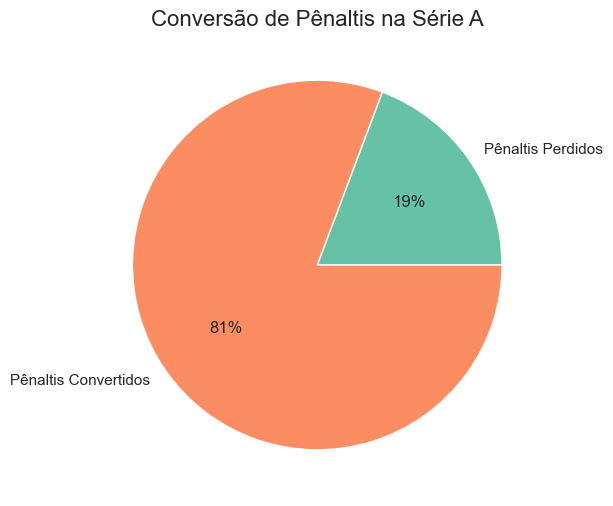

In [ ]:
# Gráfico de pizza: pênaltis convertidos vs. desperdiçados
plt.figure(figsize=(13, 6))
plt_nao_convertidos = serie_a['PKatt'].sum() - Total_GolsPenalti  
dados = [plt_nao_convertidos, Total_GolsPenalti]
rotulos = ['Pênaltis Perdidos', 'Pênaltis Convertidos']
cores = sns.color_palette('Set2')

# Cria o gráfico de pizza
plt.pie(dados, labels=rotulos, colors=cores, autopct='%.0f%%')

# Adiciona o título
plt.title('Conversão de Pênaltis na Série A', fontsize=16)

# Exibe o gráfico
plt.show()

In [ ]:
# Posições únicas

serie_a['Pos'].unique()

array(['DF', 'MF', 'MF,FW', 'FW,MF', 'FW', 'GK', 'DF,MF', 'DF,FW',
       'FW,DF', 'MF,DF'], dtype=object)

In [ ]:
# Total de jogadores FW (atacantes)

serie_a[serie_a['Pos'] == 'FW']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
6,7,Yuri Alberto,br BRA,FW,Corinthians,24.59,2001,19.0,14.0,1398.0,15.5,7.0,2.0,9.0,6.0,1.0,2.0,3.0,0.0,8.2,6.9,1.3,8.2,20.0,18.0,87.0,0.45,0.13,0.58,0.39,0.52,0.53,0.08,0.61,0.44,0.53
8,9,Alesson,br BRA,FW,Mirassol,26.68,1999,17.0,9.0,897.0,10.0,4.0,5.0,9.0,4.0,0.0,0.0,1.0,0.0,3.9,3.9,1.8,5.7,30.0,18.0,76.0,0.4,0.5,0.9,0.4,0.9,0.4,0.18,0.58,0.4,0.58
19,20,Francis Amuzu,be BEL,FW,Grêmio,26.16,1999,15.0,6.0,629.0,7.0,2.0,1.0,3.0,2.0,0.0,0.0,2.0,0.0,1.0,1.0,1.6,2.6,29.0,13.0,50.0,0.29,0.14,0.43,0.29,0.43,0.15,0.23,0.37,0.15,0.37
37,38,Matias Arezo,uy URU,FW,Grêmio,22.92,2002,8.0,3.0,268.0,3.0,1.0,1.0,2.0,1.0,0.0,0.0,1.0,0.0,0.9,0.9,0.8,1.7,4.0,5.0,17.0,0.34,0.34,0.67,0.34,0.67,0.32,0.26,0.58,0.32,0.58
38,39,Jhon Arias,co COL,FW,Fluminense,28.08,1997,12.0,12.0,1079.0,12.0,1.0,4.0,5.0,0.0,1.0,1.0,1.0,0.0,2.2,1.4,2.9,4.3,48.0,55.0,106.0,0.08,0.33,0.42,0.0,0.33,0.18,0.24,0.42,0.12,0.36
40,41,Keny Arroyo,ec ECU,FW,Cruzeiro,19.68,2006,5.0,2.0,228.0,2.5,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.5,0.5,0.7,1.2,13.0,8.0,32.0,0.0,0.39,0.39,0.0,0.39,0.18,0.29,0.47,0.18,0.47
41,42,Arthur,br BRA,FW,Sport Recife,22.61,2003,6.0,1.0,200.0,2.2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.3,0.6,1.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.14,0.13,0.27,0.14,0.27
46,47,Leo Augusto Pereira,br BRA,FW,Sport Recife,25.31,2000,9.0,7.0,543.0,6.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.9,17.0,6.0,43.0,0.0,0.17,0.17,0.0,0.17,0.16,0.16,0.32,0.16,0.32
50,51,Matheus Babi,br BRA,FW,Juventude,28.26,1997,17.0,2.0,410.0,4.6,2.0,0.0,2.0,2.0,0.0,0.0,4.0,0.0,2.0,2.0,0.1,2.1,1.0,3.0,16.0,0.44,0.0,0.44,0.44,0.44,0.45,0.02,0.47,0.45,0.47
61,62,Adam Bareiro,py PAR,FW,Fortaleza,29.24,1996,12.0,1.0,256.0,2.8,1.0,0.0,1.0,1.0,0.0,1.0,3.0,1.0,3.4,2.5,0.0,2.5,2.0,6.0,20.0,0.35,0.0,0.35,0.35,0.35,1.2,0.0,1.2,0.87,0.87


In [ ]:
# Jogadores de diferentes nacionalidades

np.size((serie_a['Nation'].unique()))

20

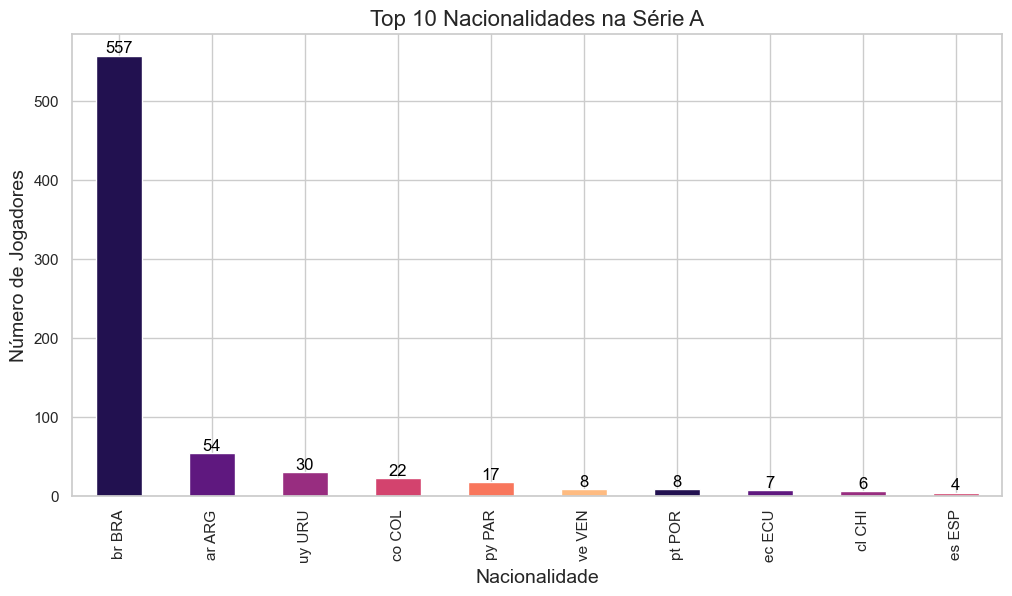

In [ ]:
# Maior número de jogadores por país

# Agrupando e ordenando os dados
nacionalidade = serie_a.groupby('Nation').size().sort_values(ascending=False)

# Criando o gráfico de barras
ax = nacionalidade.head(10).plot(kind='bar', figsize=(12, 6), color=sns.color_palette("magma"))

# Adicionando os valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a ser exibido
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionando título e rótulos dos eixos
ax.set_title('Top 10 Nacionalidades na Série A', fontsize=16)
ax.set_xlabel('Nacionalidade', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibindo o gráfico
plt.show()

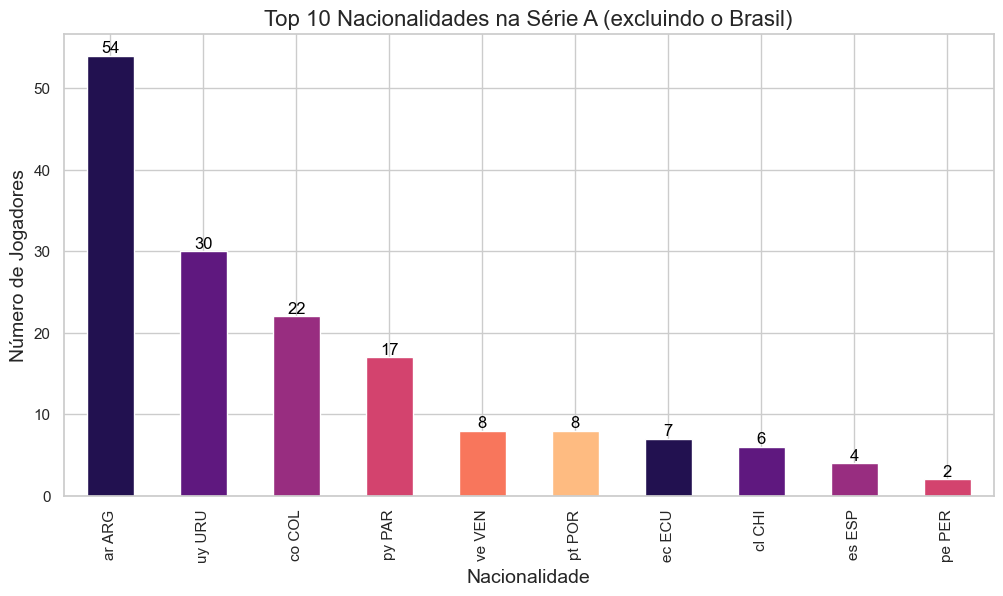

In [ ]:
# Remover jogadores brasileiros (BRA)
serie_a_sem_brasileiros = serie_a[serie_a["Nation"] != "br BRA"]

# Agrupar e ordenar por nacionalidade
nacionalidade = serie_a_sem_brasileiros.groupby("Nation").size().sort_values(ascending=False)

# Plotar top 10
ax = nacionalidade.head(10).plot(
    kind="bar",
    figsize=(12, 6),
    color=sns.color_palette("magma")
)

# Adicionar valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),
        ha="center",
        va="bottom",
        fontsize=12,
        color="black"
    )

# Títulos e rótulos dos eixos
ax.set_title("Top 10 Nacionalidades na Série A (excluindo o Brasil)", fontsize=16)
ax.set_xlabel("Nacionalidade", fontsize=14)
ax.set_ylabel("Número de Jogadores", fontsize=14)

plt.show()

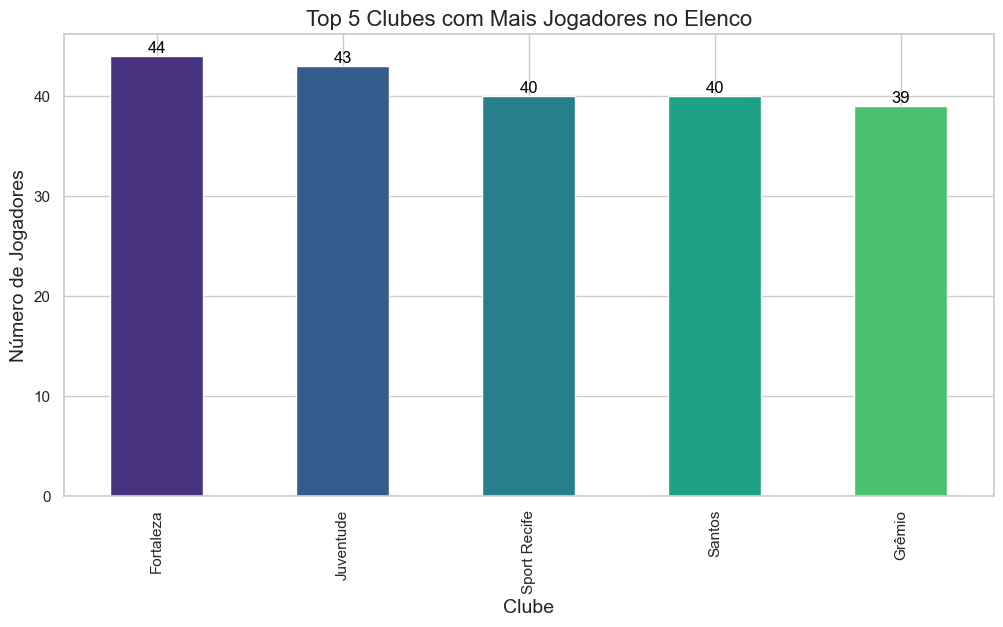

In [ ]:
# Plotando os clubes com maior número de jogadores no elenco
plt.figure(figsize=(12, 6))
top_clubes = serie_a['Squad'].value_counts().nlargest(5)
ax = top_clubes.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Mais Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

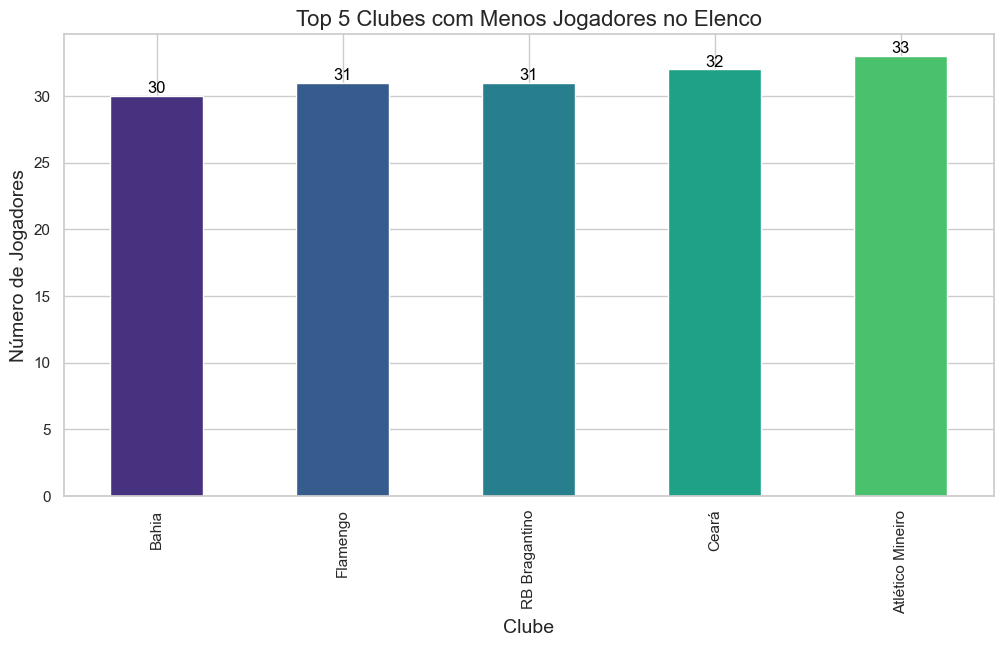

In [ ]:
# Plotando os clubes com menor número de jogadores no elenco
plt.figure(figsize=(12, 6))
clubes_com_menos_jogadores = serie_a['Squad'].value_counts().nsmallest(5)
ax = clubes_com_menos_jogadores.plot(kind='bar', color=sns.color_palette("viridis"))

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Valor a exibir
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição
        ha='center',  # Alinhamento horizontal
        va='bottom',  # Alinhamento vertical
        fontsize=12,  # Tamanho da fonte
        color='black'  # Cor da fonte
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Top 5 Clubes com Menos Jogadores no Elenco', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Exibir o gráfico
plt.show()

In [ ]:
# Jogadores por faixa etária

Abaixo20 = serie_a[serie_a['Age'] <= 20]
Idade20_25 = serie_a[(serie_a['Age'] > 20) & (serie_a['Age'] <= 25)]
Idade25_30 = serie_a[(serie_a['Age'] > 25) & (serie_a['Age'] <= 30)]
Acima30 = serie_a[serie_a['Age'] > 30]

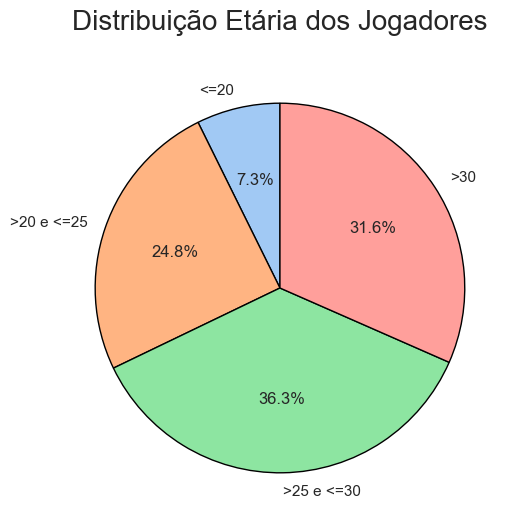

In [ ]:
# Dados
x = np.array([
    Abaixo20['Player'].count(),
    Idade20_25['Player'].count(),
    Idade25_30['Player'].count(),
    Acima30['Player'].count()
])
rotulos = ["<=20", ">20 e <=25", ">25 e <=30", ">30"] 

# Criar paleta de cores personalizada
cores = sns.color_palette("pastel")

# Plotar gráfico de pizza
plt.figure(figsize=(10, 6))  # Ajustar tamanho da figura
plt.pie(
    x, 
    labels=rotulos, 
    autopct="%.1f%%", 
    colors=cores, 
    startangle=90,  # Rotacionar para começar no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar borda para melhor contraste
)
plt.title('Distribuição Etária dos Jogadores', fontsize=20, pad=20)  # Título traduzido + espaçamento

# Exibir o gráfico
plt.show()

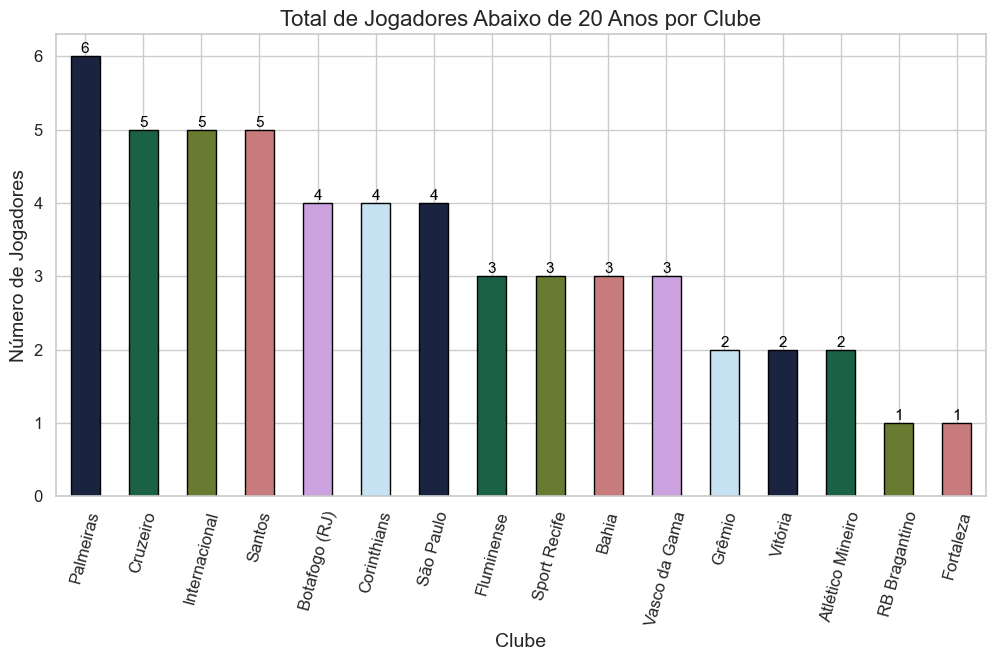

In [ ]:
# Filtrar jogadores com menos de 20 anos
jogadores_abaixo_20 = serie_a[serie_a['Age'] < 20]

# Contar jogadores abaixo de 20 anos em cada clube
contagem_abaixo_20 = jogadores_abaixo_20['Squad'].value_counts()

# Plotar os dados
plt.figure(figsize=(12, 6))
ax = contagem_abaixo_20.plot(
    kind='bar', 
    color=sns.color_palette("cubehelix"), 
    edgecolor='black'
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir a contagem
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posição no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=11, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title('Total de Jogadores Abaixo de 20 Anos por Clube', fontsize=16)
ax.set_xlabel('Clube', fontsize=14)
ax.set_ylabel('Número de Jogadores', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
plt.xticks(rotation=75, fontsize=12)
plt.yticks(fontsize=12)

# Exibir o gráfico
plt.show()

In [ ]:
# Jogadores abaixo de 20 anos no Internacional

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Internacional']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
122,123,Gabriel Carvalho,br BRA,FW,Internacional,18.18,2007,3.0,0.0,72.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,3.0,6.0,1.0,0.0,0.0,0.0,0.0,0.0,0.1,0.0,0.1,0.1,0.1
428,429,Ricardo Mathias,br BRA,FW,Internacional,19.24,2006,15.0,6.0,557.0,6.2,3.0,0.0,3.0,3.0,0.0,0.0,1.0,0.0,3.9,3.9,0.3,4.2,3.0,8.0,21.0,0.48,0.0,0.48,0.48,0.48,0.64,0.05,0.68,0.64,0.68
491,492,Luis Otávio,br BRA,MF,Internacional,18.53,2007,14.0,3.0,426.0,4.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.4,0.4,0.0,0.4,3.0,15.0,3.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.08,0.07,0.08
552,553,Raykkonen,br BRA,FW,Internacional,17.27,2008,5.0,0.0,98.0,1.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.2,0.2,0.0,0.2,1.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.14,0.0,0.14,0.14,0.14
721,722,Yago,br BRA,MF,Internacional,18.71,2007,2.0,0.0,73.0,0.8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,1.0,7.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.09,0.09,0.0,0.09


In [ ]:
# Jogadores abaixo de 20 anos no Palmeiras

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Palmeiras']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
70,71,Erick Belé,br BRA,MF,Palmeiras,18.75,2007,1.0,0.0,11.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
71,72,Luis Benedetti,br BRA,DF,Palmeiras,19.37,2006,2.0,2.0,180.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.1,0.1,0.0,0.1,0.0,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.03,0.01,0.04,0.03,0.04
200,201,Luis Felipe,br BRA,MF,Palmeiras,17.72,2008,1.0,0.0,5.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
214,215,Riquelme Fillipi,br BRA,FW,Palmeiras,19.1,2006,1.0,0.0,9.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.3,0.0,0.3,0.3,0.3
381,382,Luighi,br BRA,FW,Palmeiras,19.48,2006,7.0,2.0,237.0,2.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.3,0.3,0.5,0.8,8.0,5.0,20.0,0.0,0.0,0.0,0.0,0.0,0.12,0.19,0.31,0.12,0.31
717,718,Estêvão Willian,br BRA,"MF,FW",Palmeiras,18.49,2007,11.0,9.0,831.0,9.2,0.0,3.0,3.0,0.0,0.0,0.0,3.0,0.0,1.2,1.1,2.0,3.1,48.0,34.0,93.0,0.0,0.32,0.32,0.0,0.32,0.13,0.22,0.35,0.12,0.34


In [ ]:
# Jogadores abaixo de 20 anos no Botafogo (RJ)

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Botafogo (RJ)']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
64,65,Jordan Barrera,co COL,FW,Botafogo (RJ),19.53,2006,1.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
295,296,Huguinho,br BRA,MF,Botafogo (RJ),18.54,2007,1.0,0.0,24.0,0.3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.07,0.0,0.07,0.07,0.07
340,341,José Kadir,pa PAN,"FW,MF",Botafogo (RJ),18.26,2007,2.0,0.0,10.0,0.1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
450,451,Álvaro Montoro,ar ARG,FW,Botafogo (RJ),18.51,2007,11.0,9.0,745.0,8.3,2.0,2.0,4.0,2.0,0.0,0.0,3.0,0.0,1.9,1.9,1.8,3.8,23.0,54.0,70.0,0.24,0.24,0.48,0.24,0.48,0.23,0.22,0.46,0.23,0.46


In [ ]:
# Jogadores abaixo de 20 anos no Atlético Mineiro

jogadores_abaixo_20[jogadores_abaixo_20['Squad'] == 'Atlético Mineiro']

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90
307,308,Mateus Iseppe,br BRA,MF,Atlético Mineiro,19.47,2006,1.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
587,588,Iván Román,cl CHI,DF,Atlético Mineiro,19.28,2006,8.0,6.0,504.0,5.6,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.5,0.5,0.0,0.5,3.0,24.0,2.0,0.0,0.0,0.0,0.0,0.0,0.09,0.0,0.09,0.09,0.09


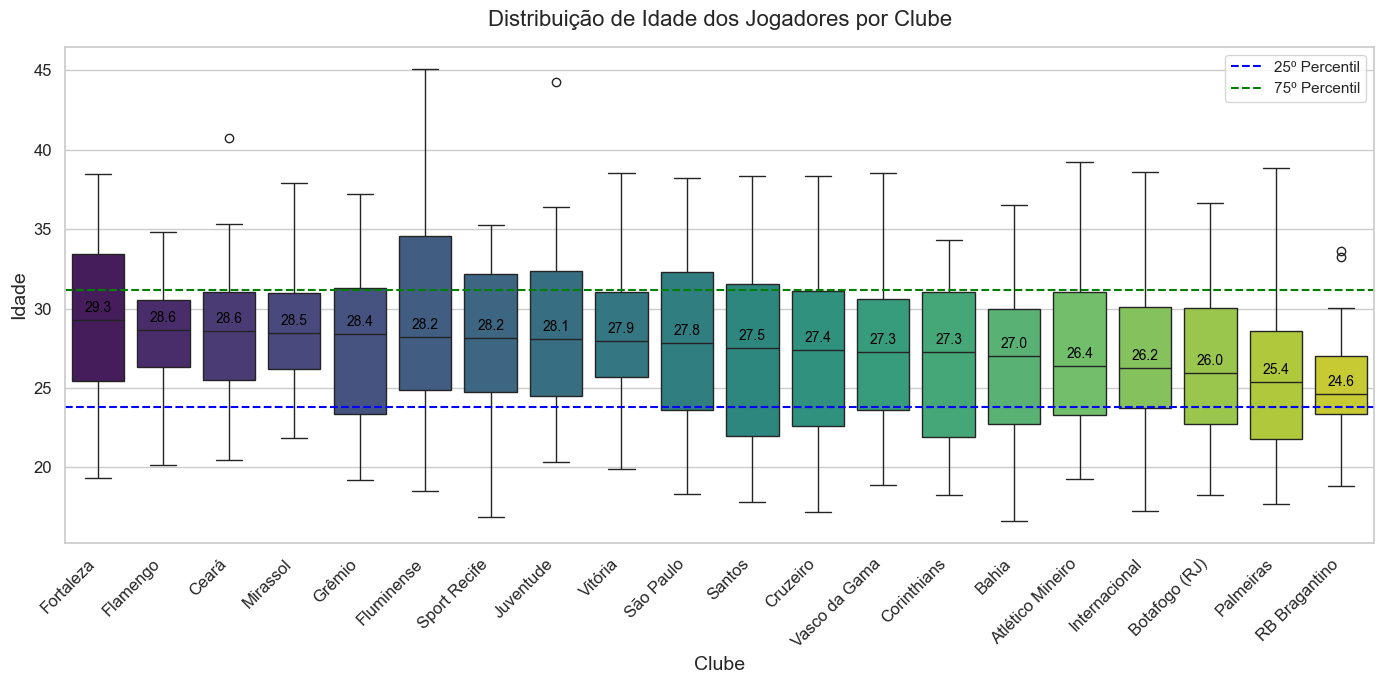

In [ ]:
# Ordenar clubes pela mediana de idade
clubes_ordenados = (
    serie_a.groupby('Squad')['Age'].median()
    .sort_values(ascending=False)
    .index
)

# Criar a figura
plt.figure(figsize=(14, 7))

# Criar o boxplot com clubes ordenados e paleta personalizada
sns.boxplot(
    x='Squad', 
    y='Age', 
    data=serie_a, 
    palette='viridis', 
    order=clubes_ordenados, 
    showfliers=True  # Defina como False para ocultar outliers, se desejar
)

# Adicionar linhas dos quartis para melhor interpretação
plt.axhline(serie_a['Age'].quantile(0.25), color='blue', linestyle='--', label='25º Percentil')
plt.axhline(serie_a['Age'].quantile(0.75), color='green', linestyle='--', label='75º Percentil')
plt.legend()

# Adicionar anotações com a mediana de idade de cada clube
medianas_idade = serie_a.groupby('Squad')['Age'].median()
for indice, clube in enumerate(clubes_ordenados):
    plt.text(
        indice, 
        medianas_idade[clube] + 0.5,  # Posicionar o texto um pouco acima da mediana
        f"{medianas_idade[clube]:.1f}",  # Exibir mediana com 1 casa decimal
        ha='center', 
        fontsize=10, 
        color='black'
    )

# Personalizar título e rótulos
plt.title('Distribuição de Idade dos Jogadores por Clube', fontsize=16, pad=15)
plt.xlabel('Clube', fontsize=14)
plt.ylabel('Idade', fontsize=14)

# Ajustar rótulos dos eixos para melhor legibilidade
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Ajustar layout para evitar sobreposição
plt.tight_layout()

# Exibir o gráfico
plt.show()

In [ ]:
# Contar número de jogadores por clube
num_jogadores = serie_a.groupby('Squad').size()

# Calcular a média de idade por clube (soma das idades / número de jogadores)
media_idade_por_clube = (serie_a.groupby('Squad')['Age'].sum()) / num_jogadores

# Arredondar para 2 casas decimais
media_idade_por_clube = media_idade_por_clube.round(2)

# Ordenar os clubes pela média de idade (do mais velho para o mais jovem)
media_idade_por_clube.sort_values(ascending=False)

Squad
Fluminense          29.09
Fortaleza           29.06
Mirassol            29.04
Ceará               28.71
Flamengo            28.26
Juventude           28.25
Vitória             28.22
Sport Recife        27.93
Grêmio              27.78
São Paulo           27.61
Vasco da Gama       27.32
Santos              27.12
Atlético Mineiro    27.11
Cruzeiro            27.08
Internacional       26.97
Corinthians         26.65
Bahia                26.6
Botafogo (RJ)       26.48
Palmeiras           25.95
RB Bragantino        25.2
dtype: Float64

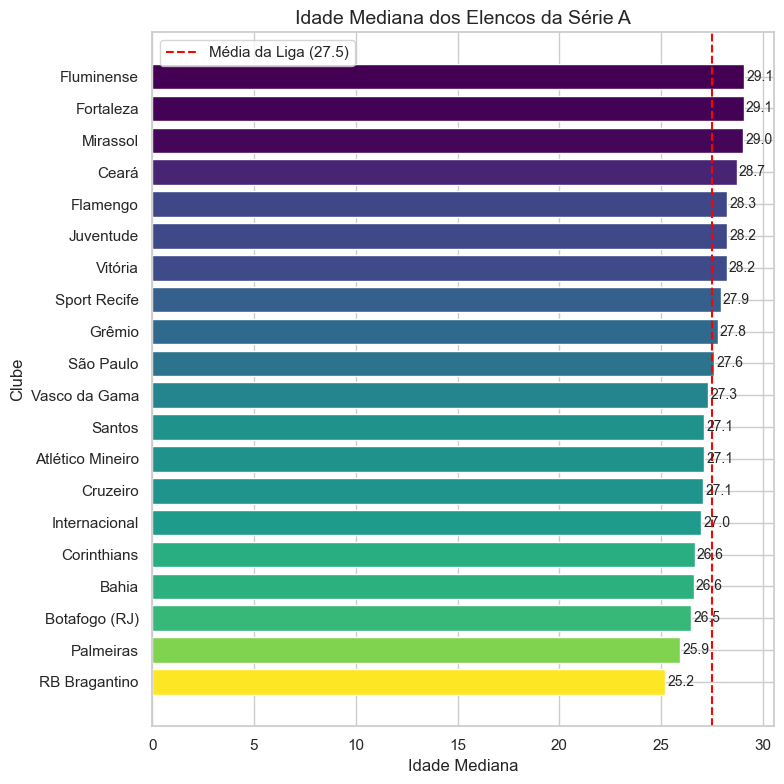

In [ ]:
# Transformar em DataFrame
df_medianas = pd.DataFrame(list(media_idade_por_clube.items()), columns=["Clube", "Idade_Mediana"])

# Média da liga
media_liga = df_medianas["Idade_Mediana"].mean()

# Ordenar do mais jovem para o mais velho
df_ordenado = df_medianas.sort_values("Idade_Mediana", ascending=True)

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

# Barras coloridas em gradiente
barras = ax.barh(
    df_ordenado["Clube"],
    df_ordenado["Idade_Mediana"],
    color=plt.cm.viridis_r(
        (df_ordenado["Idade_Mediana"] - df_ordenado["Idade_Mediana"].min()) /
        (df_ordenado["Idade_Mediana"].max() - df_ordenado["Idade_Mediana"].min())
    )
)

# Linha da média da liga
ax.axvline(media_liga, color="red", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série A", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout para evitar cortes
plt.tight_layout()

# Exibir o gráfico
plt.show()

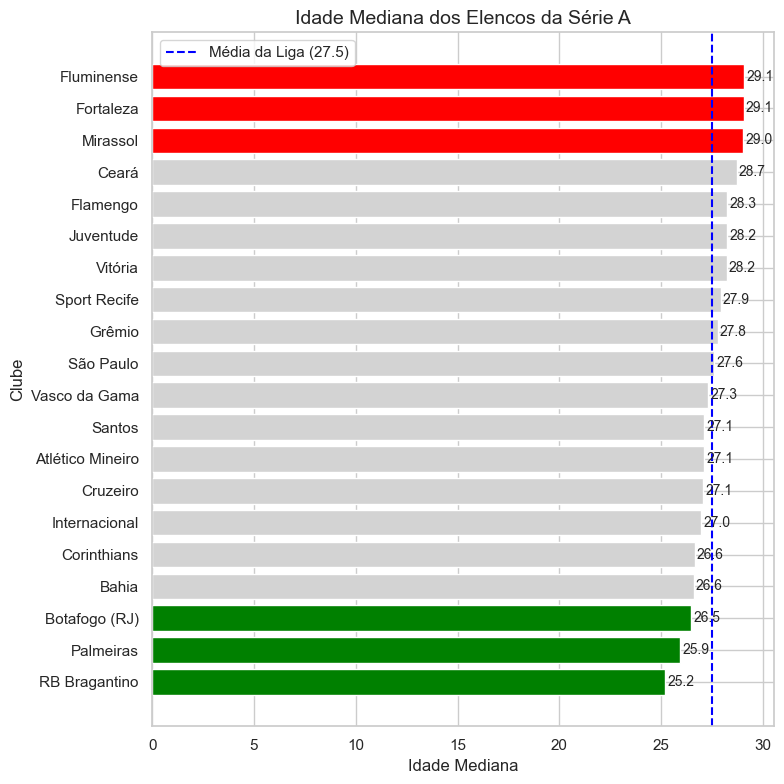

In [ ]:
# Identificar top 3 clubes mais jovens e top 3 mais experientes
mais_jovens = df_ordenado.head(3)["Clube"].tolist()
mais_experientes = df_ordenado.tail(3)["Clube"].tolist()

# Definir cores para destaque
cores = []
for clube in df_ordenado["Clube"]:
    if clube in mais_jovens:
        cores.append("green")      # destaque para os mais jovens
    elif clube in mais_experientes:
        cores.append("red")        # destaque para os mais experientes
    else:
        cores.append("lightgray")  # cor neutra para os demais

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(8, 8))

barras = ax.barh(df_ordenado["Clube"], df_ordenado["Idade_Mediana"], color=cores)

# Linha da média da liga
ax.axvline(media_liga, color="blue", linestyle="--", label=f"Média da Liga ({media_liga:.1f})")

# Valores ao lado das barras
for barra in barras:
    largura = barra.get_width()
    ax.text(largura + 0.1, barra.get_y() + barra.get_height()/2,
            f"{largura:.1f}", va="center", fontsize=10)

# Títulos e rótulos dos eixos
ax.set_title("Idade Mediana dos Elencos da Série A", fontsize=14)
ax.set_xlabel("Idade Mediana")
ax.set_ylabel("Clube")
ax.legend()

# Ajustar layout
plt.tight_layout()

# Exibir o gráfico
plt.show()


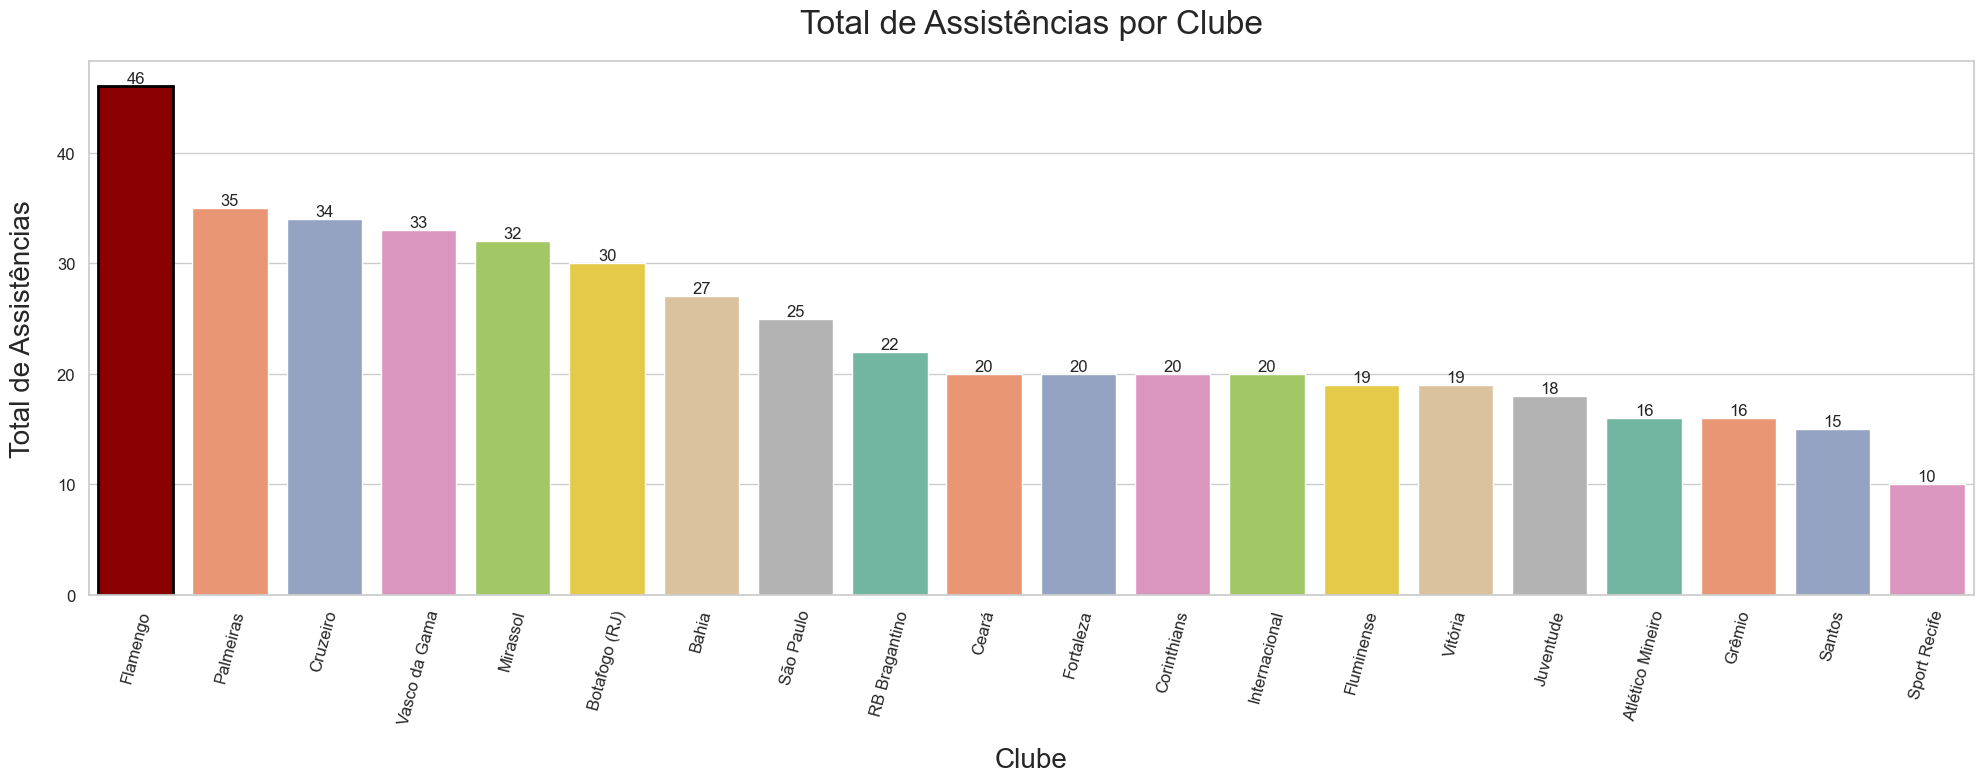

In [ ]:
# Total de assistências por clube
Assistencias_por_clube = pd.DataFrame(serie_a.groupby('Squad', as_index=False)['Ast'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Ast', 
    data=Assistencias_por_clube.sort_values(by='Ast', ascending=False),  # Ordenar clubes por assistências
    palette='Set2'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Assistências', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Assistências por Clube', fontsize=24, pad=20)

# Destacar o primeiro clube (maior número de assistências)
ax.patches[0].set_facecolor('darkred')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [ ]:
# Top 10 jogadores com mais assistências

top_10_assistencias = serie_a[['Player', 'Age', 'Squad', 'Ast', 'MP']].nlargest(n=10, columns='Ast')
top_10_assistencias

,Player,Age,Squad,Ast,MP
156,Giorgian De Arrascaeta,31.39,Flamengo,12.0,26.0
331,Kaio Jorge,23.74,Cruzeiro,7.0,26.0
430,Mauricio,24.42,Palmeiras,7.0,21.0
517,Matheus Pereira,29.46,Cruzeiro,7.0,27.0
281,Paulo Henrique,29.24,Vasco da Gama,6.0,22.0
500,Alan Patrick,34.44,Internacional,6.0,21.0
509,Pedro,28.34,Flamengo,6.0,21.0
525,Lucas Piton,25.03,Vasco da Gama,6.0,22.0
8,Alesson,26.68,Mirassol,5.0,17.0
160,Enzo Díaz,29.87,São Paulo,5.0,24.0


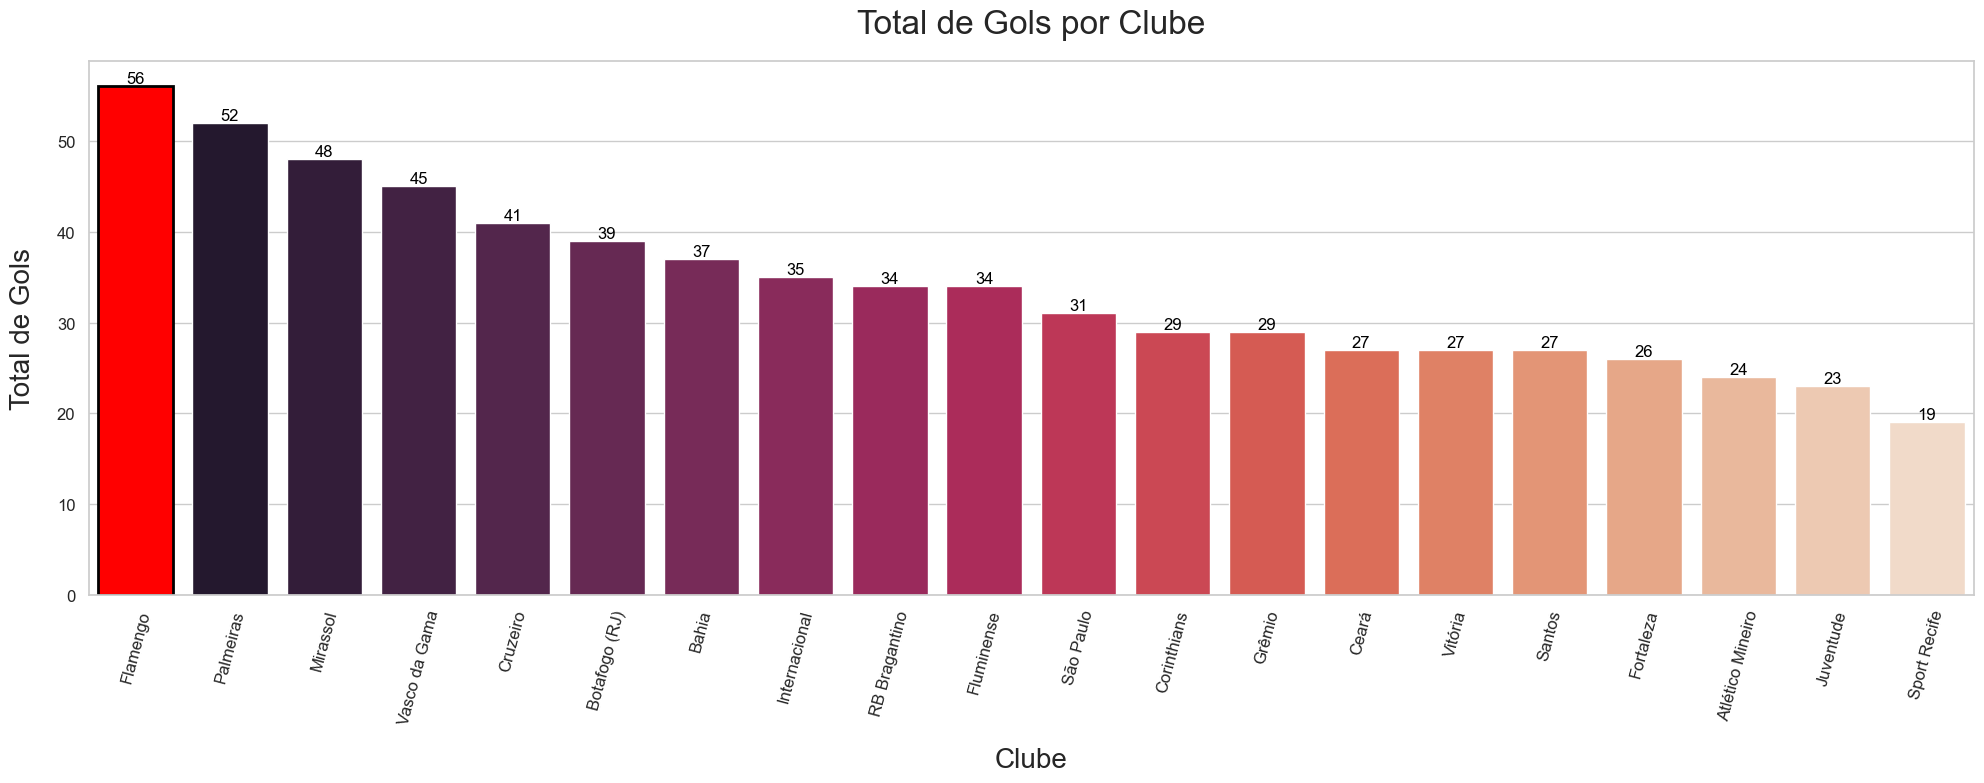

In [ ]:
# Total de gols por clube
Gols_por_clube = pd.DataFrame(serie_a.groupby('Squad', as_index=False)['Gls'].sum())

# Definir tema e tamanho da figura
sns.set_theme(style='whitegrid', color_codes=True)
plt.figure(figsize=(20, 8))

# Criar gráfico de barras
ax = sns.barplot(
    x='Squad', 
    y='Gls', 
    data=Gols_por_clube.sort_values(by='Gls', ascending=False),  # Ordenar clubes por gols
    palette='rocket'
)

# Adicionar anotações com os valores em cima das barras
for barra in ax.patches:
    ax.annotate(
        format(int(barra.get_height()), ','),  # Formatar como número inteiro com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Centralizar anotação
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar rótulos e título
ax.set_xlabel('Clube', fontsize=20, labelpad=15)
ax.set_ylabel('Total de Gols', fontsize=20, labelpad=15)
plt.xticks(rotation=75, fontsize=12)  # Rotacionar rótulos do eixo X
plt.yticks(fontsize=12)
plt.title('Total de Gols por Clube', fontsize=24, pad=20)

# Ajustar layout
plt.tight_layout()

# Destacar a primeira barra (maior número de gols)
ax.patches[0].set_facecolor('red')
ax.patches[0].set_edgecolor('black')
ax.patches[0].set_linewidth(2)

# Exibir o gráfico
plt.show()

In [ ]:
import plotly.express as px
from IPython.display import HTML

# Mapeamento de cores por clube (para manter identidade visual)
cores_por_clube = {
    "Flamengo": "red",             # vermelho e preto
    "Cruzeiro": "blue",            # azul
    "Palmeiras": "green",          # verde
    "Botafogo (RJ)": "black",      # preto e branco
    "São Paulo": "darkred",        # vermelho/preto/branco
    "RB Bragantino": "crimson",    # vermelho
    "Corinthians": "gray",         # preto/branco
    "Santos": "white",             # branco/preto
    "Grêmio": "deepskyblue",       # azul/preto/branco
    "Internacional": "firebrick",  # vermelho
    "Atlético Mineiro": "black",   # preto/branco
    "Bahia": "royalblue",          # azul/vermelho/branco
    "Ceará": "dimgray",            # preto/branco
    "Fortaleza": "dodgerblue",     # azul/vermelho/branco
    "Fluminense": "darkgreen",     # verde/grená
    "Vasco da Gama": "black",      # preto/branco
    "Sport Recife": "gold",        # vermelho/preto/amarelo
    "Vitória": "darkred",          # vermelho/preto
    "Juventude": "limegreen",      # verde
    "Mirassol": "yellowgreen"      # amarelo/verde
}

# Criar gráfico de treemap: gols por clube
fig = px.treemap(
    serie_a,
    path=["Squad"],                # Agrupar por clube
    values="Gls",                  # Tamanho proporcional aos gols
    color="Squad",                 # Cor por clube
    color_discrete_map=cores_por_clube,  # Usar cores definidas acima
    width=1200,
    height=400,
    title="Total de Gols Marcados por Clube"  # Título traduzido
)

# Ajustar margens do gráfico
fig.update_layout(margin=dict(t=50, l=25, r=25, b=25))
fig.update_traces(textinfo="label+value")

# Renderizar gráfico de forma segura no notebook
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

In [ ]:
# Jogadores com mais gols

top_10_gols = serie_a[['Player', 'Age', 'Squad', 'Gls', 'Ast', 'MP', 'Pos']].nlargest(n=10, columns=['Gls'])
top_10_gols

,Player,Age,Squad,Gls,Ast,MP,Pos
156,Giorgian De Arrascaeta,31.39,Flamengo,15.0,12.0,26.0,"MF,FW"
331,Kaio Jorge,23.74,Cruzeiro,15.0,7.0,26.0,FW
601,Vitor Roque,20.64,Palmeiras,13.0,3.0,26.0,FW
509,Pedro,28.34,Flamengo,12.0,6.0,21.0,FW
679,Pablo Vegetti,37.02,Vasco da Gama,12.0,1.0,26.0,FW
554,Reinaldo,36.06,Mirassol,11.0,5.0,28.0,DF
699,Rayan Vitor,19.22,Vasco da Gama,11.0,1.0,27.0,FW
401,José Manuel López,24.87,Palmeiras,10.0,1.0,25.0,"FW,MF"
500,Alan Patrick,34.44,Internacional,9.0,6.0,21.0,"MF,FW"
347,Renato Kayser,29.67,Vitória,8.0,0.0,21.0,FW


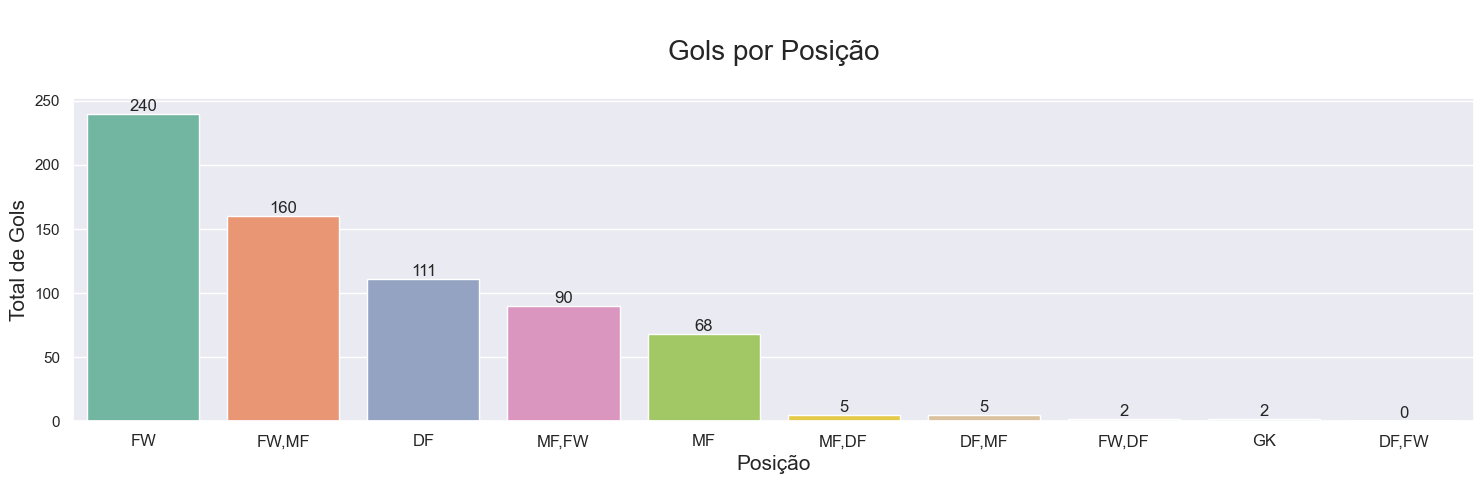

In [ ]:
# Configurar estilo do Seaborn
sns.set(rc={'figure.figsize': (15, 5)})
plt.xticks(fontsize=12)

# Agrupar por posição e somar gols
serie_a_agrupado = serie_a.groupby('Pos', as_index=False)['Gls'].sum()

# Ordenar posições por total de gols (do maior para o menor)
serie_a_agrupado = serie_a_agrupado.sort_values(by='Gls', ascending=False)

# Criar gráfico de barras
p = sns.barplot(
    data=serie_a_agrupado, 
    x='Pos', 
    y='Gls', 
    palette="Set2"
)

# Adicionar valores no topo das barras
for barra in p.patches:
    p.annotate(
        format(int(barra.get_height()), ','),  # Formatar valor com separador de milhar
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=12
    )

# Adicionar título e rótulos dos eixos
p.axes.set_title("\nGols por Posição\n", fontsize=20)
p.set_xlabel("Posição", fontsize=15)
p.set_ylabel("Total de Gols", fontsize=15)

# Melhorar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [ ]:
# Criar 2 novas colunas
serie_a['MinutosPorJogo'] = (serie_a['Min'] / serie_a['MP']).fillna(0).astype(int)
serie_a['GolsPorJogo'] = (serie_a['Gls'] / serie_a['MP']).fillna(0).astype(float)
print(serie_a)

      Rk                      Player  Nation    Pos             Squad    Age  \
0      1                       Abner  br BRA     DF         Juventude  21.51   
1      2             Nicolás Acevedo  uy URU     MF             Bahia  26.52   
2      3              Luciano Acosta  ar ARG  MF,FW        Fluminense  31.39   
3      4                       Adson  br BRA  FW,MF     Vasco da Gama  25.04   
4      5              Braian Aguirre  ar ARG     DF     Internacional  25.23   
5      6              Carlos Alberto  br BRA  FW,MF      Sport Recife  23.52   
6      7                Yuri Alberto  br BRA     FW       Corinthians  24.59   
7      8                   José Aldo  br BRA     MF          Mirassol  27.24   
8      9                     Alesson  br BRA     FW          Mirassol  26.68   
9     10              Caio Alexandre  br BRA     MF             Bahia  26.65   
10    11           Matheus Alexandre  br BRA     DF      Sport Recife  26.54   
11    12                  Alexsander  br

In [ ]:
# Gols por jogo
# Filtrar jogadores com mais de 10 jogos disputados

acima_10_jogos = serie_a[serie_a['MP'] > 10]
top_10_gols_por_jogo = acima_10_jogos[['Player', 'Age', 'Squad', 'MP', 'Min', 'Gls', 'GolsPorJogo']].nlargest(n=10, columns='GolsPorJogo')
top_10_gols_por_jogo

,Player,Age,Squad,MP,Min,Gls,GolsPorJogo
156,Giorgian De Arrascaeta,31.39,Flamengo,26.0,1894.0,15.0,0.576923
331,Kaio Jorge,23.74,Cruzeiro,26.0,2015.0,15.0,0.576923
509,Pedro,28.34,Flamengo,21.0,1047.0,12.0,0.571429
601,Vitor Roque,20.64,Palmeiras,26.0,1655.0,13.0,0.500000
141,Francisco da Costa,30.46,Mirassol,13.0,832.0,6.0,0.461538
679,Pablo Vegetti,37.02,Vasco da Gama,26.0,1973.0,12.0,0.461538
500,Alan Patrick,34.44,Internacional,21.0,1746.0,9.0,0.428571
699,Rayan Vitor,19.22,Vasco da Gama,27.0,2211.0,11.0,0.407407
401,José Manuel López,24.87,Palmeiras,25.0,1415.0,10.0,0.400000
554,Reinaldo,36.06,Mirassol,28.0,2427.0,11.0,0.392857


In [ ]:
top_10_gols_por_jogo[['Player', 'Squad', 'MP', 'Gls', 'GolsPorJogo']].style \
    .set_caption("Top 10 Jogadores em Gols por Jogo (Mín. 11 Jogos)") \
    .format({'GolsPorJogo': "{:.2f}"}) \
    .set_properties(**{'text-align': 'center', 'background-color': "#070707"})

,Player,Squad,MP,Gls,GolsPorJogo
156,Giorgian De Arrascaeta,Flamengo,26.000000,15.000000,0.58
331,Kaio Jorge,Cruzeiro,26.000000,15.000000,0.58
509,Pedro,Flamengo,21.000000,12.000000,0.57
601,Vitor Roque,Palmeiras,26.000000,13.000000,0.50
141,Francisco da Costa,Mirassol,13.000000,6.000000,0.46
679,Pablo Vegetti,Vasco da Gama,26.000000,12.000000,0.46
500,Alan Patrick,Internacional,21.000000,9.000000,0.43
699,Rayan Vitor,Vasco da Gama,27.000000,11.000000,0.41
401,José Manuel López,Palmeiras,25.000000,10.000000,0.40
554,Reinaldo,Mirassol,28.000000,11.000000,0.39


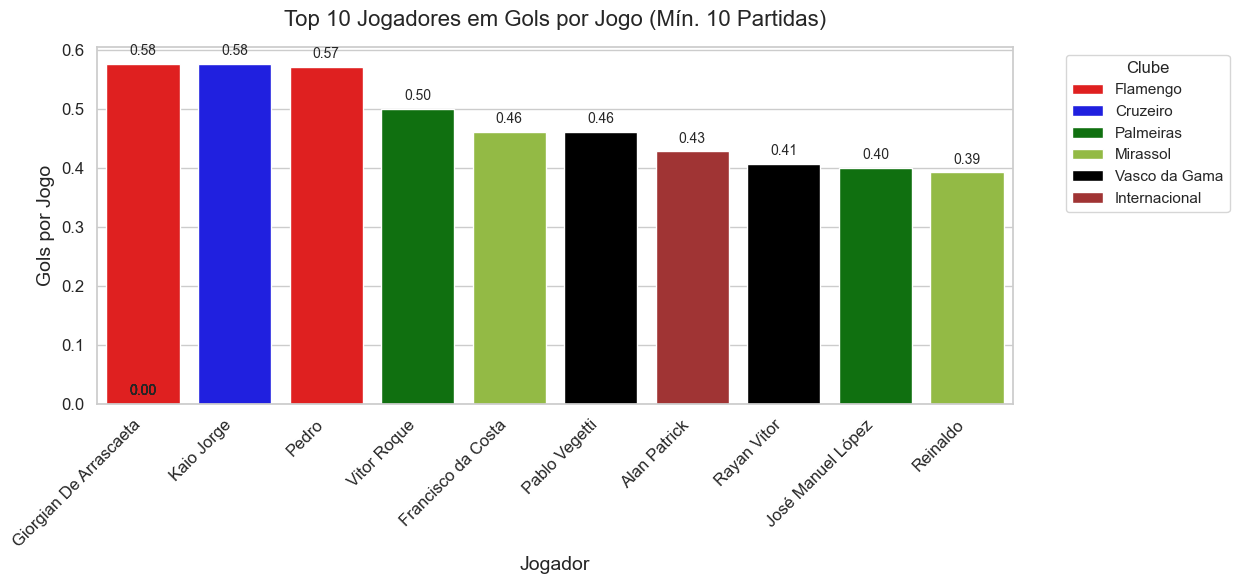

In [ ]:
# Filtrar jogadores com mais de 10 partidas jogadas
acima_10_partidas = serie_a[serie_a['MP'] > 10]

# Selecionar os 10 jogadores com melhor desempenho em GolsPorJogo
top_10_gols_por_jogo = acima_10_partidas[['Player', 'Squad', 'GolsPorJogo', 'MP', 'Gls']].nlargest(n=10, columns='GolsPorJogo')

# Plotar gráfico
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")


# Criar gráfico
ax = sns.barplot(
    data=top_10_gols_por_jogo,
    x='Player',
    y='GolsPorJogo',
    hue='Squad',
    palette=cores_por_clube,
    dodge=False
)

# Adicionar valores no topo das barras (corrigido)
for barra in ax.patches:
    valor = barra.get_height()
    valor_formatado = f"{valor:.2f}"  # Garante 2 casas decimais
    ax.annotate(
        valor_formatado,
        (barra.get_x() + barra.get_width() / 2, barra.get_height() + 0.01),
        ha='center', va='bottom', fontsize=10
    )

# Personalizar título e rótulos
ax.set_title('Top 10 Jogadores em Gols por Jogo (Mín. 10 Partidas)', fontsize=16, pad=15)
ax.set_xlabel('Jogador', fontsize=14)
ax.set_ylabel('Gols por Jogo', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=12)
plt.yticks(fontsize=12)

# Legenda fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(right=0.85)
plt.show()

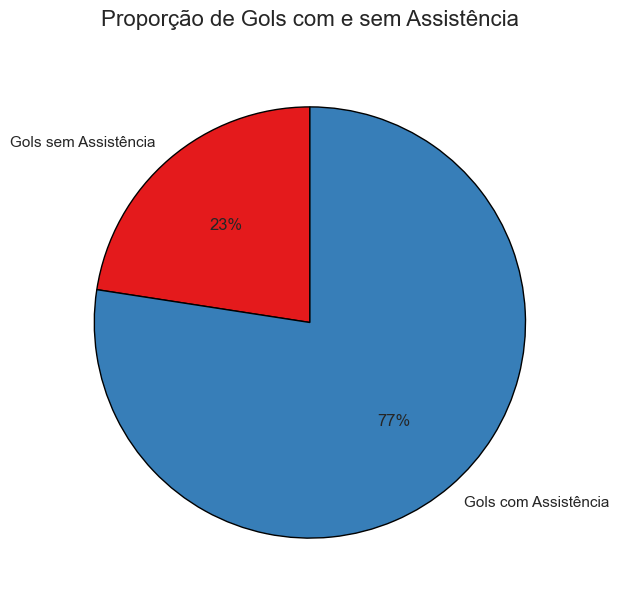

In [ ]:
# Dados para o gráfico de pizza
assistencias = serie_a['Ast'].sum()
dados = [Total_Gols - assistencias, assistencias]
rotulos = ['Gols sem Assistência', 'Gols com Assistência']
cores = sns.color_palette('Set1')

# Criar gráfico de pizza
plt.figure(figsize=(14, 7))
plt.pie(
    dados, 
    labels=rotulos, 
    colors=cores, 
    autopct='%.0f%%', 
    startangle=90,  # Iniciar o gráfico no topo
    wedgeprops={'edgecolor': 'black'}  # Adicionar bordas pretas para melhor contraste
)

# Adicionar título
plt.title('Proporção de Gols com e sem Assistência', fontsize=16, pad=20)

# Exibir o gráfico
plt.show()

In [ ]:
import plotly.express as px
from IPython.display import HTML

# Filtrar atacantes com pelo menos 900 minutos jogados
atacantes = serie_a[serie_a['Min'] >= 900]

# Criando o gráfico de dispersão
fig = px.scatter(
    atacantes,
    x="Ast_90",      # Eixo X: Gols por 90 minutos
    y="xAG_90",       # Eixo Y: xG (Expected Goals) por 90 minutos
    text="Player",   # Exibir nome dos jogadores nos pontos
    title="Relação entre Gols Marcados e xG por 90 Minutos",
    labels={
        "xG_90": "xG por 90 min (Gols Esperados)",
        "Gls_90": "Gols por 90 min"
    },
    template="plotly_white"
)

# Adicionar linha de referência: xG = Gols
fig.add_shape(
    type="line", line=dict(dash='dash', color='gray'),
    x0=atacantes['Gls_90'].min(), y0=atacantes['Gls_90'].min(),
    x1=atacantes['Gls_90'].max(), y1=atacantes['Gls_90'].max()
)

# Adicionar anotação na linha
fig.add_annotation(
    x=atacantes['Gls_90'].max() - 0.5,
    y=atacantes['Gls_90'].max() - 0.5,
    text="xG = Gols",
    showarrow=False,
    font=dict(size=12, color="gray")
)


# Ajustando posição do texto (nome dos jogadores)
fig.update_traces(textposition="top center")

# Exibir gráfico inline sem depender de renderizador externo
HTML(fig.to_html(include_plotlyjs="cdn", full_html=False))

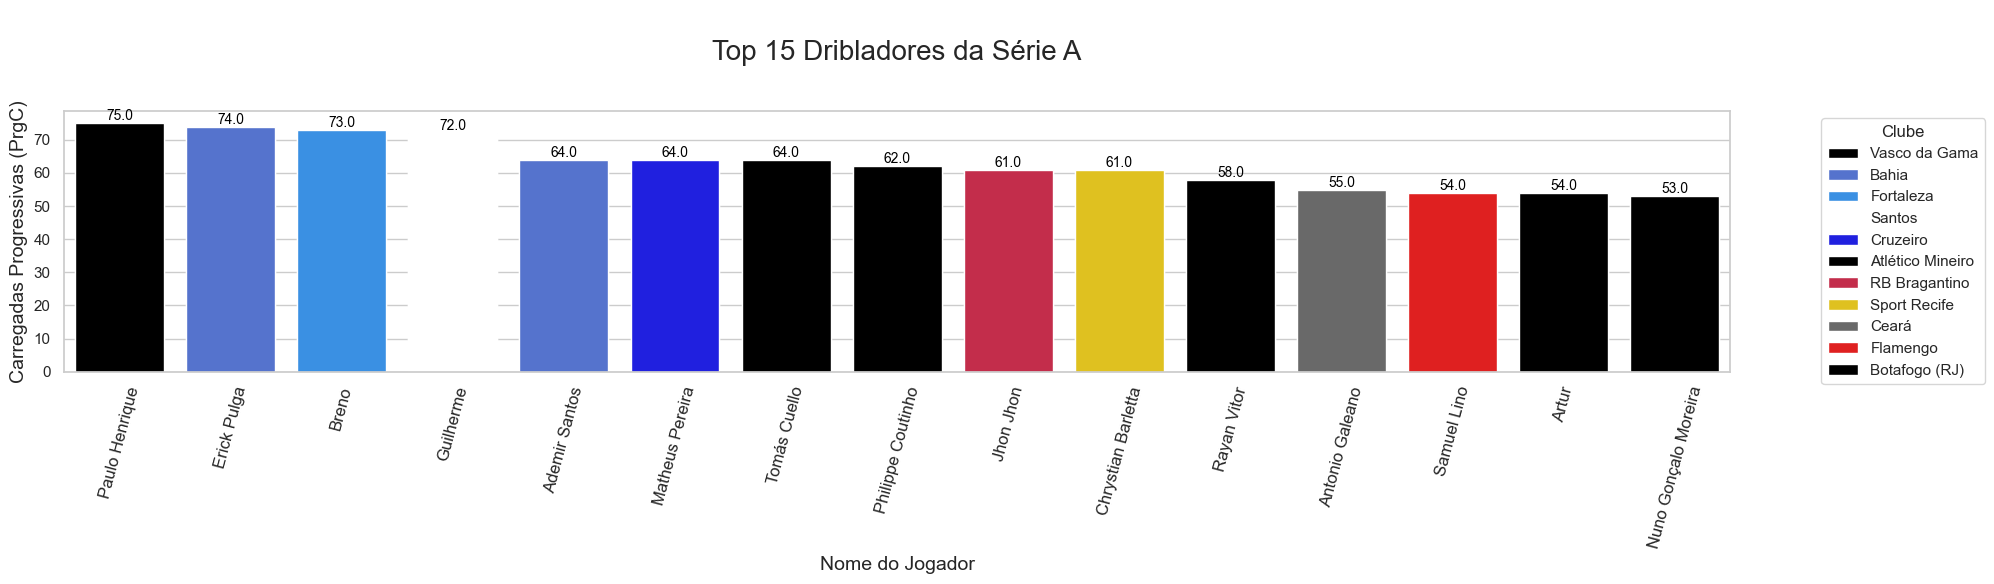

In [ ]:
# Ordenar o dataset por 'PrgC' em ordem decrescente
serie_a = serie_a.sort_values(by='PrgC', ascending=False)

# Selecionar os 15 melhores jogadores
top_dribladores = serie_a[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico de barras sem barras de erro
ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'), 
        (barra.get_x() + barra.get_width() / 2, barra.get_height()), 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Dribladores da Série A\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Carregadas Progressivas (PrgC)", fontsize=14)

ax = sns.barplot(
    x="Player", 
    y="PrgC", 
    data=top_dribladores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

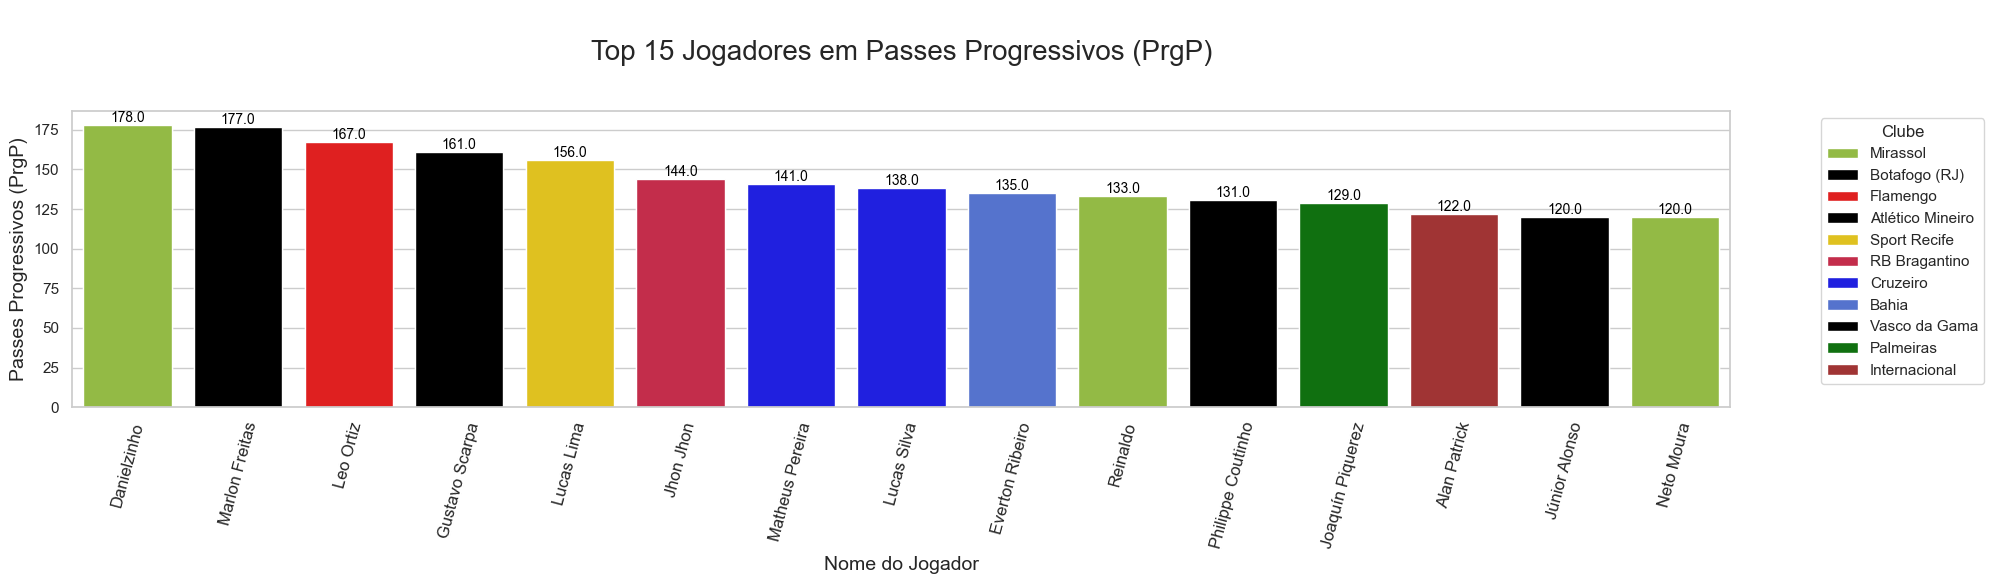

In [ ]:
# Ordenar o dataset por 'PrgP' em ordem decrescente
serie_a = serie_a.sort_values(by='PrgP', ascending=False)

# Selecionar os 15 melhores jogadores
top_passadores = serie_a[:15]

# Configurar estilo do Seaborn e tamanho da figura
sns.set(rc={'figure.figsize': (20, 6)})
sns.set_theme(style="whitegrid")
plt.xticks(fontsize=12, rotation=75)  # Rotacionar rótulos do eixo X para melhor legibilidade

# Criar gráfico de barras
ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    palette="cividis", 
    capsize=0.2, 
    ci=None  # Desativar intervalos de confiança (barras de erro)
)

# Adicionar valores no topo das barras
for barra in ax.patches:
    ax.annotate(
        format(barra.get_height(), '.1f'),  # Exibir valor com uma casa decimal
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar no topo da barra
        ha='center', 
        va='bottom', 
        fontsize=10, 
        color='black'
    )

# Adicionar título e rótulos dos eixos
ax.set_title("\nTop 15 Jogadores em Passes Progressivos (PrgP)\n", fontsize=20, pad=15)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Passes Progressivos (PrgP)", fontsize=14)


ax = sns.barplot(
    x="Player", 
    y="PrgP", 
    data=top_passadores, 
    hue="Squad",          # Agrupar por clube
    palette=cores_por_clube,  # Usar cores definidas anteriormente
    dodge=False,
    ci=None
)

# Mover legenda para fora do gráfico
ax.legend(title="Clube", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.subplots_adjust(right=0.85)  # Dar espaço para a legenda


# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [ ]:
serie_a.columns.to_list()

['Rk',
 'Player',
 'Nation',
 'Pos',
 'Squad',
 'Age',
 'Born',
 'MP',
 'Starts',
 'Min',
 '90s',
 'Gls',
 'Ast',
 'G+A',
 'G-PK',
 'PK',
 'PKatt',
 'CrdY',
 'CrdR',
 'xG',
 'npxG',
 'xAG',
 'npxG+xAG',
 'PrgC',
 'PrgP',
 'PrgR',
 'Gls_90',
 'Ast_90',
 'G+A_90',
 'G-PK_90',
 'G+A-PK_90',
 'xG_90',
 'xAG_90',
 'xG+xAG_90',
 'npxG_90',
 'npxG+xAG_90',
 'MinutosPorJogo',
 'GolsPorJogo']

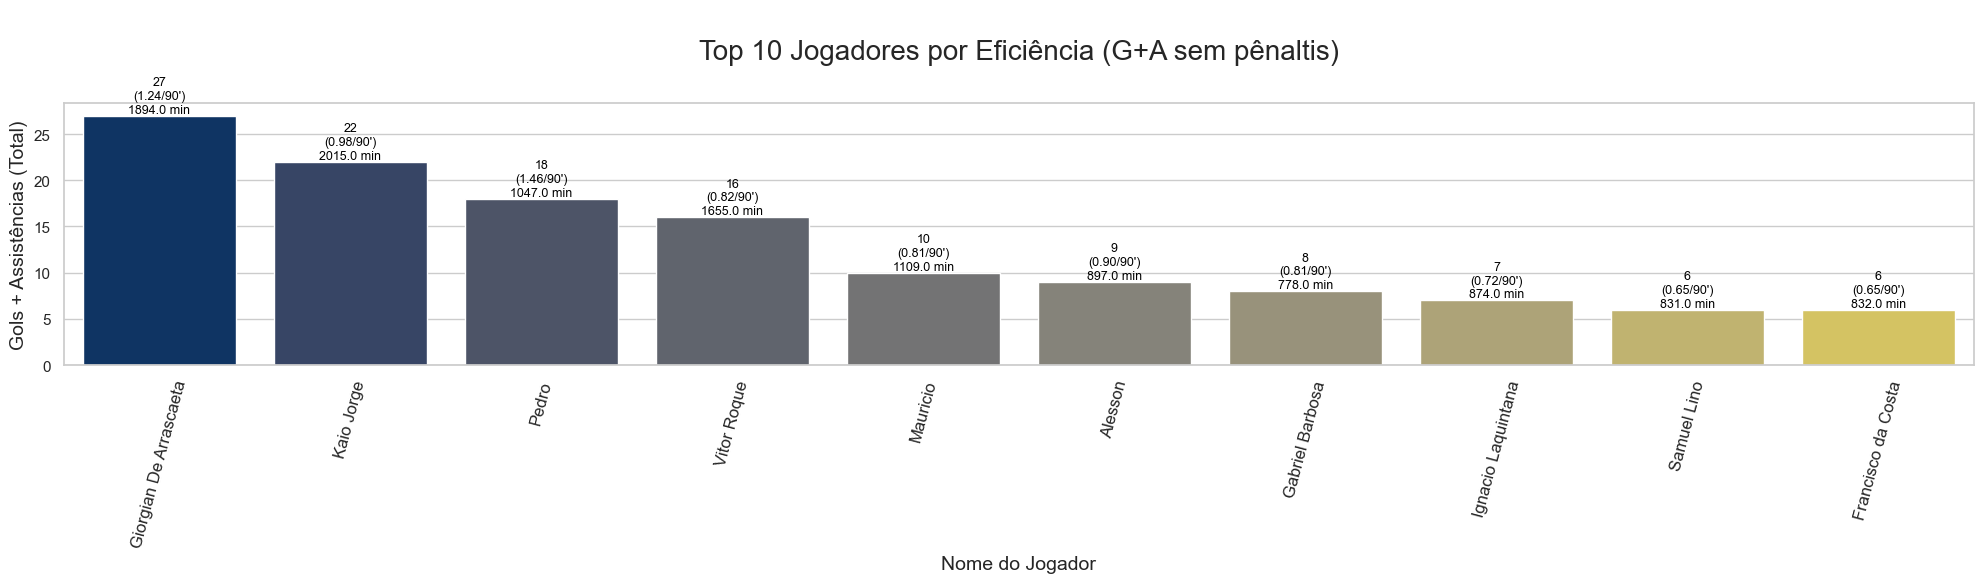

In [ ]:
# Criar coluna G+A (se ainda não existir)
serie_a['G+A'] = serie_a['Gls'] + serie_a['Ast']

# Filtrar jogadores com pelo menos 8 jogos (90s >= 8)
serie_a_filtrada = serie_a[serie_a['90s'] >= 8]

# Ordenar por eficiência (G+A-PK_90) — para selecionar os mais eficientes
serie_a_ordenada = serie_a_filtrada.sort_values(by='G+A-PK_90', ascending=False)

# Selecionar os 10 melhores
top_jogadores = serie_a_ordenada.head(10)

# Reordenar por G+A total (para exibição visual)
top_jogadores_ordem_plot = top_jogadores.sort_values(by='G+A', ascending=False)

# Configurar estilo
sns.set_theme(style="whitegrid", rc={'figure.figsize': (20, 6)})
plt.xticks(fontsize=12, rotation=75)

# Criar gráfico
ax = sns.barplot(
    x="Player",
    y="G+A",
    data=top_jogadores_ordem_plot,
    palette="cividis"
)

# Adicionar valores totais e eficiência
for i, barra in enumerate(ax.patches):
    jogador = top_jogadores_ordem_plot.iloc[i]
    valor_total = barra.get_height()
    eficiencia = jogador['G+A-PK_90']
    minutos = jogador['Min']
    
    ax.annotate(
        f"{valor_total:.0f}\n({eficiencia:.2f}/90')\n{minutos} min",
        (barra.get_x() + barra.get_width() / 2, valor_total),
        ha='center', va='bottom', fontsize=9, color='black'
    )

# Título e rótulos
ax.set_title("\nTop 10 Jogadores por Eficiência (G+A sem pênaltis)\n", fontsize=20, pad=10)
ax.set_xlabel("Nome do Jogador", fontsize=14)
ax.set_ylabel("Gols + Assistências (Total)", fontsize=14)

plt.tight_layout()
plt.show()

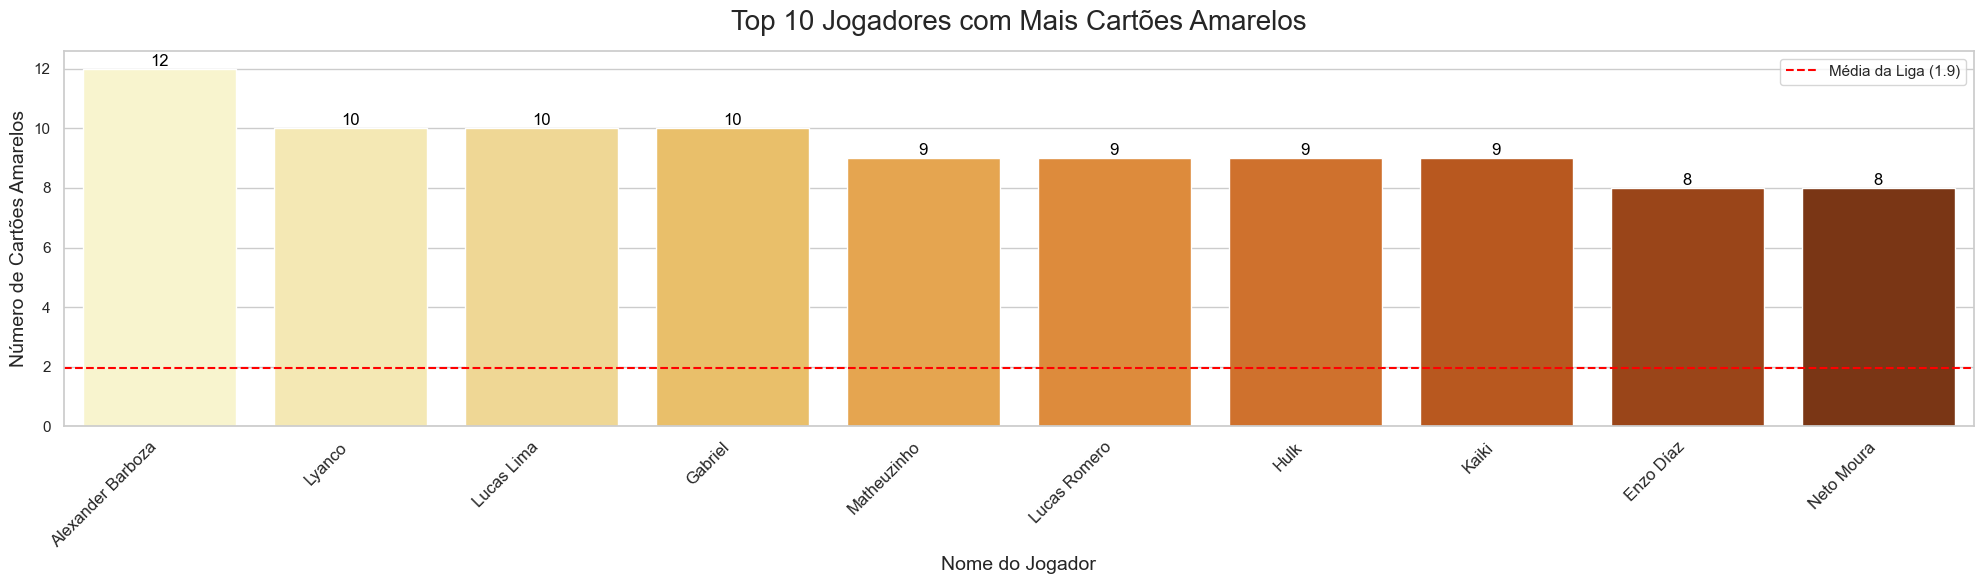

In [ ]:
# Ordenar o dataset por cartões amarelos e selecionar os 10 jogadores com mais cartões
serie_a_amarelos = serie_a.sort_values(by='CrdY', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_a_amarelos['Player'], 
    y=serie_a_amarelos['CrdY'], 
    palette="YlOrBr"  # Paleta de cores em gradiente amarelo/laranja (temática de cartões)
)

# Adicionar anotações com o número de cartões amarelos
for barra in ax.patches:
    ax.annotate(
        f'{int(barra.get_height())}',  # Exibir contagem de cartões como número inteiro
        (barra.get_x() + barra.get_width() / 2, barra.get_height()),  # Posicionar acima da barra
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='black'
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Amarelos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Amarelos', fontsize=14)

# Rotacionar rótulos do eixo X para melhor legibilidade
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

media_liga = serie_a['CrdY'].mean()
ax.axhline(media_liga, color='red', linestyle='--', label=f'Média da Liga ({media_liga:.1f})')
ax.legend()

# Ajustar layout e exibir o gráfico
plt.tight_layout()
plt.show()

In [ ]:
serie_a_amarelos

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,MinutosPorJogo,GolsPorJogo
60,61,Alexander Barboza,ar ARG,DF,Botafogo (RJ),30.6,1995,18.0,18.0,1607.0,17.9,0.0,0.0,0.0,0.0,0.0,0.0,12.0,0.0,0.5,0.5,0.1,0.5,15.0,75.0,9.0,0.0,0.0,0.0,0.0,0.0,0.03,0.0,0.03,0.03,0.03,89,0.000000
386,387,Lyanco,br BRA,DF,Atlético Mineiro,28.72,1997,17.0,17.0,1410.0,15.7,0.0,0.0,0.0,0.0,0.0,0.0,10.0,2.0,0.6,0.6,0.1,0.7,11.0,62.0,1.0,0.0,0.0,0.0,0.0,0.0,0.04,0.01,0.05,0.04,0.05,82,0.000000
365,366,Lucas Lima,br BRA,"MF,FW",Sport Recife,35.28,1990,24.0,21.0,1805.0,20.1,3.0,5.0,8.0,2.0,1.0,1.0,10.0,0.0,2.7,1.9,3.9,5.8,44.0,156.0,87.0,0.15,0.25,0.4,0.1,0.35,0.13,0.19,0.33,0.09,0.29,75,0.125000
233,234,Gabriel,br BRA,MF,RB Bragantino,33.28,1992,25.0,24.0,1940.0,21.6,1.0,0.0,1.0,1.0,0.0,0.0,10.0,0.0,0.5,0.5,0.6,1.1,12.0,77.0,19.0,0.05,0.0,0.05,0.05,0.05,0.02,0.03,0.05,0.02,0.05,77,0.040000
427,428,Matheuzinho,br BRA,DF,Corinthians,25.12,2000,24.0,22.0,2047.0,22.7,2.0,3.0,5.0,2.0,0.0,0.0,9.0,0.0,0.9,0.9,3.4,4.4,52.0,108.0,121.0,0.09,0.13,0.22,0.09,0.22,0.04,0.15,0.19,0.04,0.19,85,0.083333
591,592,Lucas Romero,ar ARG,MF,Cruzeiro,31.51,1994,26.0,25.0,2207.0,24.5,1.0,2.0,3.0,1.0,0.0,0.0,9.0,0.0,0.5,0.5,1.5,1.9,20.0,115.0,25.0,0.04,0.08,0.12,0.04,0.12,0.02,0.06,0.08,0.02,0.08,84,0.038462
296,297,Hulk,br BRA,"FW,MF",Atlético Mineiro,39.24,1986,23.0,19.0,1788.0,19.9,4.0,3.0,7.0,3.0,1.0,1.0,9.0,0.0,3.7,2.9,3.1,6.0,31.0,44.0,129.0,0.2,0.15,0.35,0.15,0.3,0.19,0.16,0.34,0.15,0.3,77,0.173913
341,342,Kaiki,br BRA,DF,Cruzeiro,22.62,2003,26.0,26.0,2293.0,25.5,1.0,3.0,4.0,1.0,0.0,0.0,9.0,0.0,3.1,3.1,2.8,5.9,50.0,80.0,118.0,0.04,0.12,0.16,0.04,0.16,0.12,0.11,0.23,0.12,0.23,88,0.038462
160,161,Enzo Díaz,ar ARG,DF,São Paulo,29.87,1995,24.0,17.0,1607.0,17.9,0.0,5.0,5.0,0.0,0.0,0.0,8.0,0.0,0.3,0.3,5.0,5.4,45.0,93.0,80.0,0.0,0.28,0.28,0.0,0.28,0.02,0.28,0.3,0.02,0.3,66,0.000000
458,459,Neto Moura,br BRA,MF,Mirassol,29.21,1996,26.0,26.0,1977.0,22.0,1.0,0.0,1.0,1.0,0.0,0.0,8.0,0.0,0.2,0.2,0.4,0.6,5.0,120.0,18.0,0.05,0.0,0.05,0.05,0.05,0.01,0.02,0.03,0.01,0.03,76,0.038462


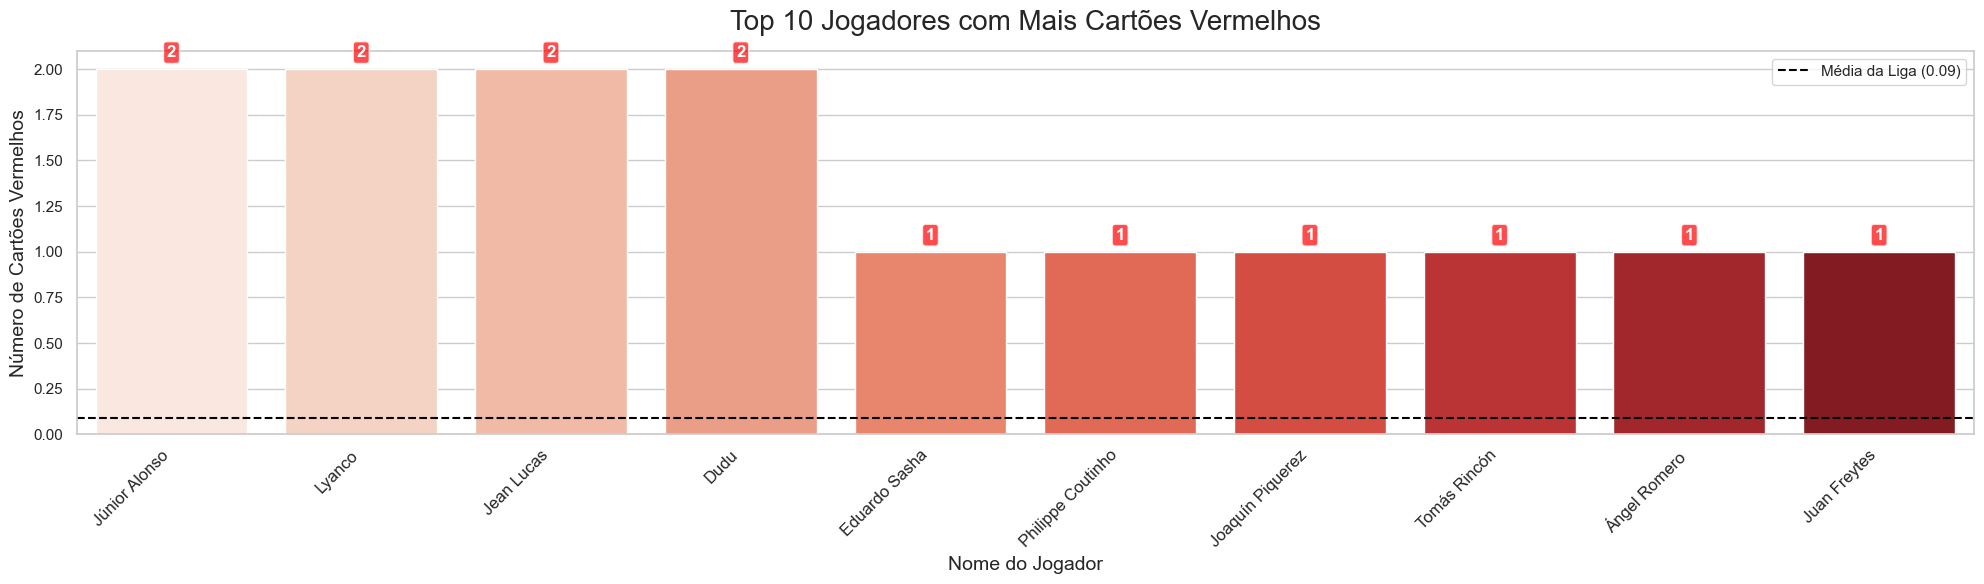

In [ ]:
# Ordenar o dataset por cartões vermelhos e selecionar os 10 jogadores com mais cartões
serie_a_vermelhos = serie_a.sort_values(by='CrdR', ascending=False).head(10)

# Configurar tamanho da figura e estilo
plt.figure(figsize=(20, 6))
sns.set_theme(style="whitegrid")

# Criar gráfico de barras
ax = sns.barplot(
    x=serie_a_vermelhos['Player'], 
    y=serie_a_vermelhos['CrdR'], 
    palette="Reds"  # Paleta de gradiente vermelho
)

# Adicionar anotações com o número de cartões vermelhos — POSICIONADAS ACIMA DA BARRA
for barra in ax.patches:
    altura = barra.get_height()
    # Posicionar o texto UM POUCO ACIMA da barra para melhor visibilidade
    ax.annotate(
        f'{int(altura)}',  # Número inteiro de cartões
        (barra.get_x() + barra.get_width() / 2, altura + 0.05),  # 👈 Deslocamento vertical +0.05
        ha='center', 
        va='bottom', 
        fontsize=12, 
        color='white',
        fontweight='bold',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="red", alpha=0.7)  # Fundo arredondado para destacar
    )

# Personalizar título e rótulos dos eixos
ax.set_title('Top 10 Jogadores com Mais Cartões Vermelhos', fontsize=20, pad=15)
ax.set_xlabel('Nome do Jogador', fontsize=14)
ax.set_ylabel('Número de Cartões Vermelhos', fontsize=14)

# Adicionar linha da média da liga
media_liga = serie_a['CrdR'].mean()
ax.axhline(media_liga, color='black', linestyle='--', label=f'Média da Liga ({media_liga:.2f})')
ax.legend()

# Rotacionar rótulos do eixo X
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=12)

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [ ]:
serie_a_vermelhos

,Rk,Player,Nation,Pos,Squad,Age,Born,MP,Starts,Min,90s,Gls,Ast,G+A,G-PK,PK,PKatt,CrdY,CrdR,xG,npxG,xAG,npxG+xAG,PrgC,PrgP,PrgR,Gls_90,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,MinutosPorJogo,GolsPorJogo
17,18,Júnior Alonso,py PAR,DF,Atlético Mineiro,32.7,1993,23.0,23.0,1948.0,21.6,0.0,1.0,1.0,0.0,0.0,0.0,3.0,2.0,0.4,0.4,0.2,0.6,22.0,120.0,15.0,0.0,0.05,0.05,0.0,0.05,0.02,0.01,0.03,0.02,0.03,84,0.000000
386,387,Lyanco,br BRA,DF,Atlético Mineiro,28.72,1997,17.0,17.0,1410.0,15.7,0.0,0.0,0.0,0.0,0.0,0.0,10.0,2.0,0.6,0.6,0.1,0.7,11.0,62.0,1.0,0.0,0.0,0.0,0.0,0.0,0.04,0.01,0.05,0.04,0.05,82,0.000000
377,378,Jean Lucas,br BRA,MF,Bahia,27.33,1998,25.0,24.0,1954.0,21.7,3.0,1.0,4.0,3.0,0.0,0.0,2.0,2.0,2.1,2.1,2.6,4.8,47.0,89.0,97.0,0.14,0.05,0.18,0.14,0.18,0.1,0.12,0.22,0.1,0.22,78,0.120000
174,175,Dudu,br BRA,MF,Vitória,26.38,1999,4.0,1.0,108.0,1.2,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,1.2,1.2,0.0,1.2,1.0,16.0,3.0,0.0,0.0,0.0,0.0,0.0,0.99,0.02,1.01,0.99,1.01,27,0.000000
622,623,Eduardo Sasha,br BRA,"FW,MF",RB Bragantino,33.65,1992,25.0,22.0,1647.0,18.3,5.0,2.0,7.0,3.0,2.0,2.0,5.0,1.0,7.1,5.6,1.4,7.0,22.0,36.0,91.0,0.27,0.11,0.38,0.16,0.27,0.39,0.08,0.47,0.3,0.38,65,0.200000
142,143,Philippe Coutinho,br BRA,MF,Vasco da Gama,33.36,1992,23.0,23.0,1806.0,20.1,5.0,3.0,8.0,5.0,0.0,0.0,1.0,1.0,3.4,3.4,3.2,6.6,62.0,131.0,92.0,0.25,0.15,0.4,0.25,0.4,0.17,0.16,0.33,0.17,0.33,78,0.217391
523,524,Joaquín Piquerez,uy URU,DF,Palmeiras,27.16,1998,26.0,24.0,2142.0,23.8,3.0,1.0,4.0,1.0,2.0,3.0,2.0,1.0,3.1,0.7,2.9,3.6,29.0,129.0,140.0,0.13,0.04,0.17,0.04,0.08,0.13,0.12,0.25,0.03,0.15,82,0.115385
568,569,Tomás Rincón,ve VEN,MF,Santos,37.77,1988,16.0,11.0,909.0,10.1,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,0.4,0.4,0.0,0.4,4.0,40.0,11.0,0.0,0.0,0.0,0.0,0.0,0.03,0.0,0.04,0.03,0.04,56,0.000000
590,591,Ángel Romero,py PAR,"FW,MF",Corinthians,33.3,1992,23.0,10.0,962.0,10.7,0.0,1.0,1.0,0.0,0.0,0.0,4.0,1.0,2.5,2.5,1.1,3.6,19.0,36.0,69.0,0.0,0.09,0.09,0.0,0.09,0.24,0.1,0.34,0.24,0.34,41,0.000000
224,225,Juan Freytes,ar ARG,DF,Fluminense,25.78,2000,24.0,24.0,2159.0,24.0,0.0,0.0,0.0,0.0,0.0,0.0,6.0,1.0,0.6,0.6,0.1,0.7,15.0,90.0,6.0,0.0,0.0,0.0,0.0,0.0,0.02,0.01,0.03,0.02,0.03,89,0.000000


## Jogadores com mais partidas

In [ ]:
# Quantos jogos cada clube já disputou
jogos_por_time = serie_a.groupby("Squad")["MP"].max().sort_values(ascending=False)

print(jogos_por_time)


Squad
Mirassol            29.0
Vasco da Gama       29.0
Atlético Mineiro    28.0
Botafogo (RJ)       28.0
Santos              28.0
Ceará               28.0
Fluminense          28.0
Flamengo            28.0
Vitória             28.0
São Paulo           27.0
Cruzeiro            27.0
Juventude           27.0
Sport Recife        27.0
RB Bragantino       27.0
Palmeiras           26.0
Corinthians         26.0
Bahia               25.0
Fortaleza           25.0
Internacional       25.0
Grêmio              24.0
Name: MP, dtype: Float64


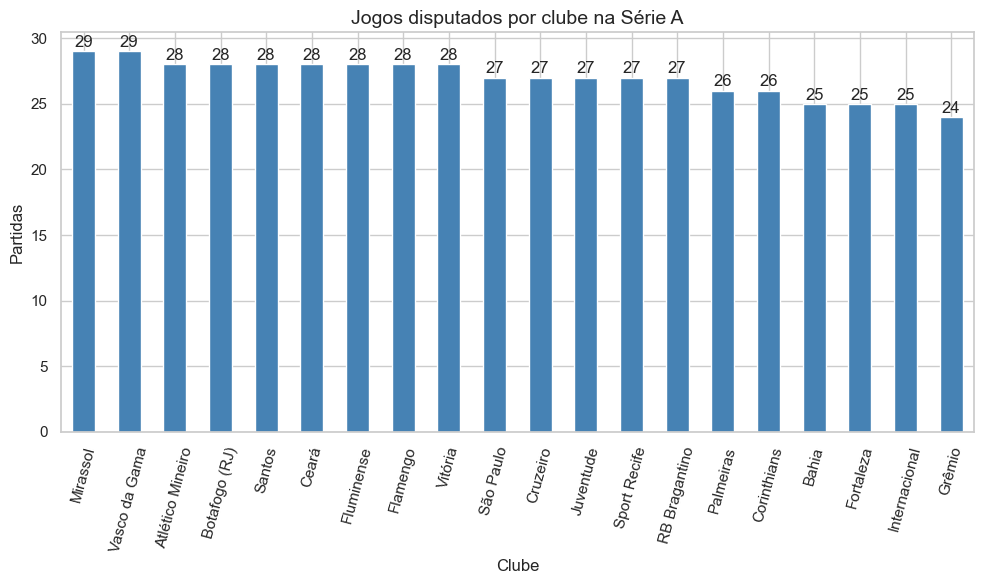

In [ ]:
import matplotlib.pyplot as plt

jogos_por_time = serie_a.groupby("Squad")["MP"].max().sort_values(ascending=False)

# Plot
fig, ax = plt.subplots(figsize=(10,6))
jogos_por_time.plot(kind="bar", color="steelblue", ax=ax)

# Adicionar rótulos em cima
for i, v in enumerate(jogos_por_time):
    ax.text(i, v + 0.1, str(int(v)), ha='center', va='bottom')

ax.set_title("Jogos disputados por clube na Série A", fontsize=14)
ax.set_ylabel("Partidas")
ax.set_xlabel("Clube")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


In [ ]:
# Top jogadores com mais jogos
top_jogadores = serie_a.sort_values("Min", ascending=False)[["Player","Pos","Squad","MP","Min"]]

print(top_jogadores.head(15))


              Player Pos             Squad    MP     Min
323           Jemmes  DF          Mirassol  29.0  2610.0
604    Agustín Rossi  GK          Flamengo  28.0  2520.0
196            Fábio  GK        Fluminense  28.0  2520.0
36     Lucas Arcanjo  GK           Vitória  28.0  2520.0
318       Léo Jardim  GK     Vasco da Gama  28.0  2515.0
92    Gabriel Brazão  GK            Santos  28.0  2497.0
151      Danielzinho  MF          Mirassol  28.0  2496.0
524     Rafael Pires  GK         São Paulo  27.0  2430.0
554         Reinaldo  DF          Mirassol  28.0  2427.0
388  Willian Machado  DF             Ceará  27.0  2409.0
312           Jadson  MF         Juventude  27.0  2395.0
123           Cássio  GK          Cruzeiro  27.0  2366.0
98    Fabrício Bruno  DF          Cruzeiro  26.0  2340.0
192          Éverson  GK  Atlético Mineiro  26.0  2340.0
713         Wéverton  GK         Palmeiras  26.0  2340.0


In [ ]:
# Média de jogos por posição
jogos_por_pos = serie_a.groupby("Pos")["MP"].mean().sort_values(ascending=False)
print(jogos_por_pos.round(2))


Pos
FW,MF    14.12
MF,FW    13.12
MF       12.54
GK        12.3
DF        12.0
FW       11.67
MF,DF    11.21
DF,FW      9.5
DF,MF      9.0
FW,DF      7.4
Name: MP, dtype: Float64


In [ ]:
import pandas as pd

def top_n_jogos_por_pos(df, n=5, min_minutos=0):
    d = df.copy()

    # garantir tipos numéricos
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")

    # normalizar posição (pega a primeira da lista)
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )

    # filtro opcional por minutos
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # ordenar por posição, depois MP e Min (desempate)
    d = d.sort_values(["Pos_simple", "MP", "Min"], ascending=[True, False, False])

    # pegar top N por posição
    out = (d.groupby("Pos_simple")
             .head(n)[["Pos_simple", "Player", "Squad", "MP", "Min"]]
             .reset_index(drop=True))
    return out

top5_por_pos = top_n_jogos_por_pos(serie_a, n=5, min_minutos=0)

for pos, bloco in top5_por_pos.groupby("Pos_simple"):
    print(f"\n=== {pos} ===")
    print(bloco.drop(columns="Pos_simple").reset_index(drop=True).to_string(index=False))



=== DF ===
         Player            Squad    MP     Min
         Jemmes         Mirassol  29.0  2610.0
       Reinaldo         Mirassol  28.0  2427.0
        Vitinho    Botafogo (RJ)  28.0  2174.0
       Natanael Atlético Mineiro  28.0  1886.0
Willian Machado            Ceará  27.0  2409.0

=== FW ===
              Player         Squad    MP     Min
Nuno Gonçalo Moreira Vasco da Gama  29.0  2094.0
     Antonio Galeano         Ceará  28.0  2332.0
         Rayan Vitor Vasco da Gama  27.0  2211.0
  Chrystian Barletta  Sport Recife  27.0  1341.0
          Pedro Raul         Ceará  26.0  2239.0

=== GK ===
        Player         Squad    MP     Min
 Lucas Arcanjo       Vitória  28.0  2520.0
         Fábio    Fluminense  28.0  2520.0
 Agustín Rossi      Flamengo  28.0  2520.0
    Léo Jardim Vasco da Gama  28.0  2515.0
Gabriel Brazão        Santos  28.0  2497.0

=== MF ===
         Player            Squad    MP     Min
    Danielzinho         Mirassol  28.0  2496.0
 Gustavo Scarpa Atlético

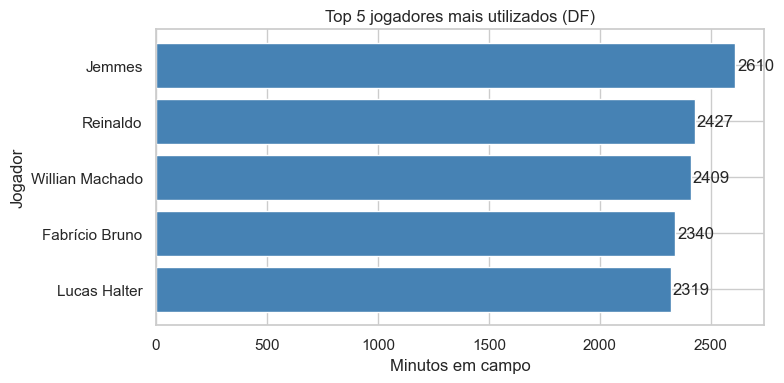

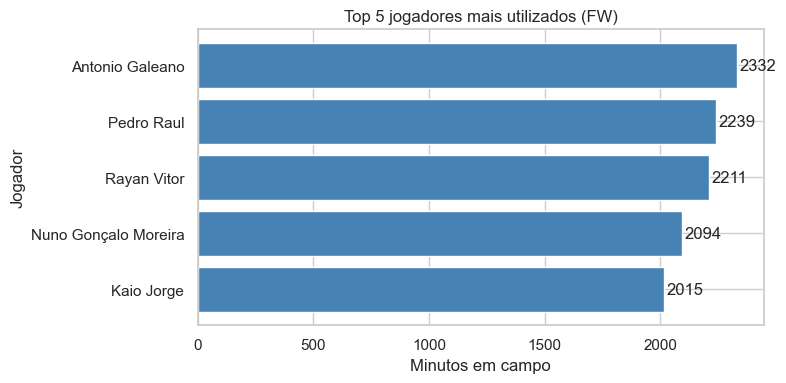

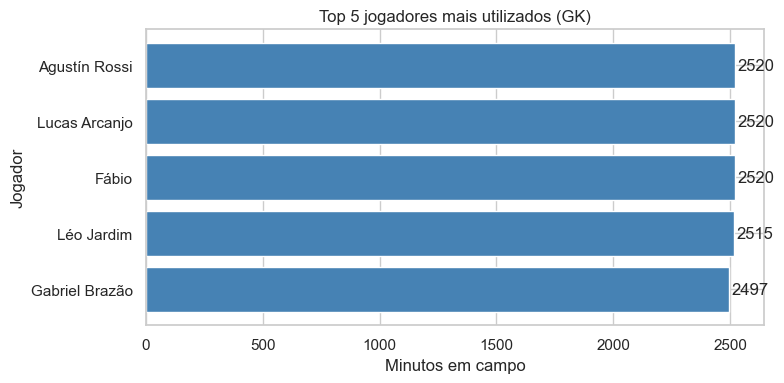

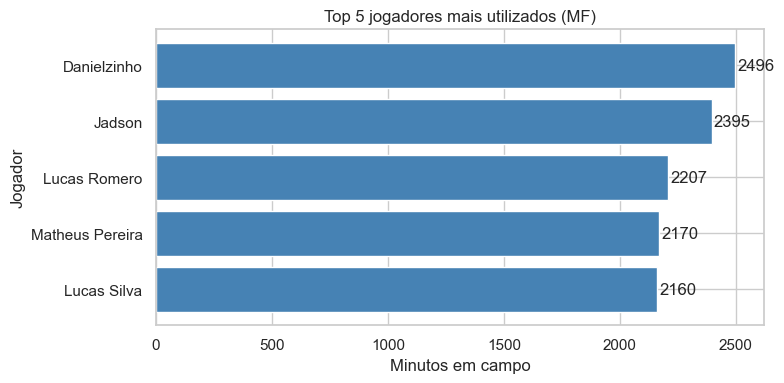

In [ ]:
import matplotlib.pyplot as plt

def plot_top5_por_pos(df, n=5, min_minutos=0):
    d = df.copy()
    d["MP"]  = pd.to_numeric(d["MP"], errors="coerce")
    d["Min"] = pd.to_numeric(d["Min"], errors="coerce")
    d["Pos_simple"] = (
        d["Pos"].astype(str)
                .str.split(",|/|;")
                .str[0]
                .str.strip()
    )
    if min_minutos > 0:
        d = d[d["Min"] >= min_minutos]

    # Ordenar por posição e minutos
    d = d.sort_values(["Pos_simple","Min"], ascending=[True,False])

    # Top N por posição
    top5 = d.groupby("Pos_simple").head(n)

    # Plotar cada posição separada
    posicoes = top5["Pos_simple"].unique()
    for pos in posicoes:
        bloco = top5[top5["Pos_simple"] == pos].sort_values("Min", ascending=True)

        plt.figure(figsize=(8,4))
        plt.barh(bloco["Player"], bloco["Min"], color="steelblue")
        plt.title(f"Top {n} jogadores mais utilizados ({pos})")
        plt.xlabel("Minutos em campo")
        plt.ylabel("Jogador")

        # rótulos nos valores
        for i, v in enumerate(bloco["Min"]):
            plt.text(v + 10, i, str(int(v)), va="center")

        plt.tight_layout()
        plt.show()

# Executar
plot_top5_por_pos(serie_a, n=5, min_minutos=900)


In [ ]:
df_goleiros = pd.read_csv(r'G:\pythonProject\Aula_Cbf\data\processed\goalkepper_stats.csv', sep=',')
df_goleiros.head(2)

In [ ]:
# Converter a coluna 'Saves' para numérico (forçando erros a virarem NaN)
df_goleiros['Saves'] = pd.to_numeric(df_goleiros['Saves'], errors='coerce')


top_2_saves = df_goleiros.nlargest(2, 'Saves')

# Exibir apenas as colunas relevantes
print(top_2_saves[['Player', 'Squad', 'Saves']])